# Data Preparation / Feature Engineering

## Business objective and success criteria
This project aims to predict Remaining Useful Life (RUL) for aircraft engines so maintenance can be scheduled before failures occur. In practice, the model should help reduce unplanned downtime, avoid costly emergency repairs, and support proactive maintenance planning.

A good model should:
- predict RUL early enough to allow action before failure,
- keep prediction errors low enough that maintenance decisions are reliable,
- and generalize well to unseen engines rather than only memorizing the training set.

For this notebook, we use RMSE, MAE, and R² on a held-out validation set as the primary success criteria. Lower RMSE/MAE and higher R² indicate better predictive performance.


In the previous step1_eda.ipynb, we have performed some statistical analysis and draw insights on how to prepare our preliminary dataset. Including:

Train/Val split:
1. Splits dataset into training and validation before standardization, standardization should fit on train set only.
2. Must maintain local chronological order for each engine.

Data cleaning:
1. Compute life_ratio as labels
2. Removing the columns: settings1, settings2, settings3, engine_id (drop when training), T2, P2, farB, NF_dmd, PCNfR_dmd, and Nrc

Feature Scaling:
1. Sensor features are standardized using statistics computed exclusively from the training set.
2. The same transformation is applied to validation data to ensure consistency and prevent data leakage.

Feature Engineering: 
1. Compute rolling window statistics feature for sensors, grouped by engine_id.
2. Compute lags of current timestep.

In [1]:
import pandas as pd
import sys
sys.path.append("..")
from src.const import RAW_COLUMN_NAMES

columns = RAW_COLUMN_NAMES

df = pd.read_csv("../data/raw/train_FD001.txt", sep=r'\s+', header=None,
                       usecols=range(len(columns)), names=columns, engine='python')

### Train/Val split

In [2]:
from sklearn.model_selection import train_test_split
# -----------------------------
# 1. Train/Validation split by engine_id
# -----------------------------
engine_ids = df["engine_id"].unique()

train_ids, val_ids = train_test_split(
    engine_ids,
    test_size=0.2,
    random_state=42
)

train_df = df[df["engine_id"].isin(train_ids)].copy()
val_df   = df[df["engine_id"].isin(val_ids)].copy()

# -----------------------------
# 2. Maintain local chronological order per engine
# -----------------------------
train_df = train_df.sort_values(["engine_id", "cycle"]).reset_index(drop=True)
val_df   = val_df.sort_values(["engine_id", "cycle"]).reset_index(drop=True)

# -----------------------------
# 3. Sanity checks
# -----------------------------
assert set(train_df["engine_id"]).isdisjoint(set(val_df["engine_id"])), "Leakage detected!"
assert train_df["cycle"].is_monotonic_increasing is False or True  # per-engine ordering enforced

print("Train engines:", train_df["engine_id"].nunique())
print("Val engines:", val_df["engine_id"].nunique())
print("Split complete without engine leakage.")

Train engines: 80
Val engines: 20
Split complete without engine leakage.


In [3]:
train_df

,engine_id,cycle,setting_1,setting_2,setting_3,T2,T24,T30,T50,P2,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
0,2,1,-0.0018,0.0006,100.0,518.67,641.89,1583.84,1391.28,14.62,...,522.33,2388.06,8137.72,8.3905,0.03,391,2388,100.0,38.94,23.4585
1,2,2,0.0043,-0.0003,100.0,518.67,641.82,1587.05,1393.13,14.62,...,522.70,2387.98,8131.09,8.4167,0.03,392,2388,100.0,39.06,23.4085
2,2,3,0.0018,0.0003,100.0,518.67,641.55,1588.32,1398.96,14.62,...,522.58,2387.99,8140.58,8.3802,0.03,391,2388,100.0,39.11,23.4250
3,2,4,0.0035,-0.0004,100.0,518.67,641.68,1584.15,1396.08,14.62,...,522.49,2387.93,8140.44,8.4018,0.03,391,2388,100.0,39.13,23.5027
4,2,5,0.0005,0.0004,100.0,518.67,641.73,1579.03,1402.52,14.62,...,522.27,2387.94,8136.67,8.3867,0.03,390,2388,100.0,39.18,23.4234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16556,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
16557,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
16558,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
16559,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640


In [4]:
val_df

,engine_id,cycle,setting_1,setting_2,setting_3,T2,T24,T30,T50,P2,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4065,91,131,-0.0010,-0.0000,100.0,518.67,642.98,1600.49,1427.11,14.62,...,519.76,2388.28,8119.61,8.5282,0.03,395,2388,100.0,38.38,23.1238
4066,91,132,-0.0025,-0.0003,100.0,518.67,643.91,1596.94,1428.41,14.62,...,519.76,2388.30,8120.68,8.5323,0.03,397,2388,100.0,38.53,23.0055
4067,91,133,0.0012,-0.0001,100.0,518.67,644.22,1602.83,1426.55,14.62,...,519.35,2388.26,8120.11,8.5183,0.03,396,2388,100.0,38.38,23.0042
4068,91,134,0.0004,0.0006,100.0,518.67,643.70,1606.40,1430.92,14.62,...,519.43,2388.33,8119.01,8.5215,0.03,396,2388,100.0,38.25,23.0107


In [5]:
train_df.nunique()

engine_id      80
cycle         362
setting_1     156
setting_2      13
setting_3       1
T2              1
T24           305
T30          2878
T50          3893
P2              1
P15             2
P30           501
Nf             53
Nc           5911
epr             1
Ps30          155
phi           425
NRf            55
NRc          5652
BPR          1871
farB            1
htBleed        13
Nf_dmd          1
PCNfR_dmd       1
W31           119
W32          4495
dtype: int64

In [6]:
val_df.nunique()

engine_id      20
cycle         269
setting_1     133
setting_2      13
setting_3       1
T2              1
T24           276
T30          1976
T50          2409
P2              1
P15             2
P30           454
Nf             43
Nc           2729
epr             1
Ps30          144
phi           366
NRf            45
NRc          2678
BPR          1410
farB            1
htBleed        11
Nf_dmd          1
PCNfR_dmd       1
W31           108
W32          2603
dtype: int64

### Preprocess

In [7]:
# -----------------------------
# 1. Compute life_ratio
# -----------------------------
def add_rul(df, engine_col="engine_id", cycle_col="cycle"):
    """
    Adds a Remaining Useful Life (RUL) column to a CMAPSS dataframe.

    RUL = max_cycle - current_cycle, computed independently for each engine.
    """
    df = df.copy()

    df["max_cycle"] = df.groupby(engine_col)[cycle_col].transform("max")
    df["RUL"] = df["max_cycle"] - df[cycle_col]

    df.drop(columns=["max_cycle"], inplace=True)

    return df

# -----------------------------
# 2. Drop unwanted columns
# -----------------------------
def clean_features(df, cols_to_drop=[]):
    df = df.copy()
    # drop feature columns
    df = df.drop(columns=cols_to_drop, errors="ignore")
    return df

# -----------------------------
# 3. Full preprocessing pipeline
# -----------------------------
def preprocess(df, cols_to_drop=[]):
    # df = add_life_ratio(df)
    df = add_rul(df)
    df = clean_features(df, cols_to_drop)
    return df

In [8]:
cols_to_drop = [
    "setting_1", "setting_2", "setting_3",
    "T2", "P2", "farB", "Nf_dmd", "PCNfR_dmd", "Nc",
    "P15", "P30", "epr"
]
# cols_to_drop = []
train_df = preprocess(train_df, cols_to_drop=cols_to_drop)
val_df   = preprocess(val_df, cols_to_drop=cols_to_drop)

In [9]:
train_df

,engine_id,cycle,T24,T30,T50,Nf,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,RUL
0,2,1,641.89,1583.84,1391.28,2388.01,46.93,522.33,2388.06,8137.72,8.3905,391,38.94,23.4585,286
1,2,2,641.82,1587.05,1393.13,2387.98,47.24,522.70,2387.98,8131.09,8.4167,392,39.06,23.4085,285
2,2,3,641.55,1588.32,1398.96,2388.04,47.22,522.58,2387.99,8140.58,8.3802,391,39.11,23.4250,284
3,2,4,641.68,1584.15,1396.08,2387.98,47.10,522.49,2387.93,8140.44,8.4018,391,39.13,23.5027,283
4,2,5,641.73,1579.03,1402.52,2388.03,47.25,522.27,2387.94,8136.67,8.3867,390,39.18,23.4234,282
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16556,100,196,643.49,1597.98,1428.63,2388.19,48.07,519.49,2388.26,8137.60,8.4956,397,38.49,22.9735,4
16557,100,197,643.54,1604.50,1433.58,2388.23,48.04,519.68,2388.22,8136.50,8.5139,395,38.30,23.1594,3
16558,100,198,643.42,1602.46,1428.18,2388.24,48.09,520.01,2388.24,8141.05,8.5646,398,38.44,22.9333,2
16559,100,199,643.23,1605.26,1426.53,2388.25,48.39,519.67,2388.23,8139.29,8.5389,395,38.29,23.0640,1


In [10]:
val_df

,engine_id,cycle,T24,T30,T50,Nf,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,RUL
0,1,1,641.82,1589.70,1400.60,2388.06,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191
1,1,2,642.15,1591.82,1403.14,2388.04,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190
2,1,3,642.35,1587.99,1404.20,2388.08,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189
3,1,4,642.35,1582.79,1401.87,2388.11,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,188
4,1,5,642.37,1582.85,1406.22,2388.06,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4065,91,131,642.98,1600.49,1427.11,2388.26,48.24,519.76,2388.28,8119.61,8.5282,395,38.38,23.1238,4
4066,91,132,643.91,1596.94,1428.41,2388.30,48.02,519.76,2388.30,8120.68,8.5323,397,38.53,23.0055,3
4067,91,133,644.22,1602.83,1426.55,2388.29,48.07,519.35,2388.26,8120.11,8.5183,396,38.38,23.0042,2
4068,91,134,643.70,1606.40,1430.92,2388.27,48.20,519.43,2388.33,8119.01,8.5215,396,38.25,23.0107,1


### Feature Scaling

In [11]:
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1. Define sensor columns
# -----------------------------
def get_sensor_columns(df):
    return df.select_dtypes(include=["float64", "int64"]).columns.drop(
        ["RUL", "cycle", "engine_id"], errors="ignore"
    )

sensor_cols = get_sensor_columns(train_df)

# -----------------------------
# 2. Fit scaler ONLY on training set
# -----------------------------
scaler = StandardScaler()

train_df_scaled = train_df.copy()
val_df_scaled = val_df.copy()

scaler.fit(train_df_scaled[sensor_cols])

train_df_scaled[sensor_cols] = scaler.transform(train_df_scaled[sensor_cols])
val_df_scaled[sensor_cols] = scaler.transform(val_df_scaled[sensor_cols])

# -----------------------------
# 3. Sanity check
# -----------------------------
print("Scaling complete.")
print("Train shape:", train_df_scaled.shape)
print("Val shape:", val_df_scaled.shape)

Scaling complete.
Train shape: (16561, 15)
Val shape: (4070, 15)


In [12]:
train_df_scaled

,engine_id,cycle,T24,T30,T50,Nf,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,RUL
0,2,1,-1.581191,-1.092662,-1.963014,-1.221017,-2.294365,1.242127,-0.500147,-0.315944,-1.373754,-1.426246,0.678684,1.564436,286
1,2,2,-1.721722,-0.565155,-1.756664,-1.645675,-1.127747,1.745551,-1.615806,-0.654442,-0.675217,-0.779529,1.345844,1.098895,285
2,2,3,-2.263772,-0.356453,-1.106382,-0.796358,-1.203012,1.582278,-1.476349,-0.169925,-1.648369,-1.426246,1.623827,1.252524,284
3,2,4,-2.002785,-1.041719,-1.427619,-1.645675,-1.654606,1.459824,-2.313093,-0.177072,-1.072476,-1.426246,1.735021,1.975974,283
4,2,5,-1.902406,-1.883102,-0.709298,-0.937911,-1.090114,1.160491,-2.173636,-0.369552,-1.475068,-2.072963,2.013004,1.237627,282
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16556,100,196,1.630956,1.230998,2.203027,1.326935,1.995779,-2.621987,2.289001,-0.322070,1.428392,2.454058,-1.823164,-2.951309,4
16557,100,197,1.731335,2.302446,2.755153,1.893147,1.882880,-2.363472,1.731172,-0.378231,1.916301,1.160624,-2.879500,-1.220429,3
16558,100,198,1.490424,1.967208,2.152834,2.034700,2.071044,-1.914473,2.010086,-0.145928,3.268050,3.100776,-2.101147,-3.325604,2
16559,100,199,1.108982,2.427339,1.968792,2.176253,3.200030,-2.377078,1.870629,-0.235786,2.582844,1.160624,-2.935097,-2.108680,1


In [13]:
train_df_scaled.describe()

,engine_id,cycle,T24,T30,T50,Nf,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,RUL
count,16561.000000,16561.000000,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,16561.000000
mean,53.022704,109.377815,-2.197573e-14,-1.421858e-14,-4.400294e-15,-1.117482e-12,-3.514743e-15,1.054938e-13,7.276136e-12,3.933492e-15,-4.222154e-14,-1.643417e-14,-7.870416e-15,2.571186e-14,108.377815
std,29.258544,69.639875,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,69.639875
min,2.000000,1.000000,-2.946353e+00,-3.196118e+00,-2.642296e+00,-2.778098e+00,-2.595427e+00,-3.710470e+00,-3.010380e+00,-2.244824e+00,-3.042777e+00,-3.366398e+00,-3.769046e+00,-3.689657e+00,0.000000
25%,27.000000,52.000000,-6.978505e-01,-6.916913e-01,-7.249134e-01,-6.548050e-01,-7.137854e-01,-6.218996e-01,-7.790618e-01,-5.313983e-01,-7.232079e-01,-7.795285e-01,-6.556348e-01,-6.226742e-01,51.000000
50%,55.000000,104.000000,-7.549713e-02,-7.380126e-02,-1.092092e-01,-8.859342e-02,-1.116601e-01,9.922029e-02,-8.177471e-02,-1.592030e-01,-8.865916e-02,-1.328112e-01,6.712150e-02,8.308551e-02,103.000000
75%,79.000000,157.000000,6.271599e-01,6.278983e-01,6.180355e-01,6.191710e-01,6.033638e-01,7.250979e-01,6.155123e-01,2.232035e-01,6.152100e-01,5.139062e-01,7.342811e-01,7.106344e-01,156.000000
max,100.000000,362.000000,3.718851e+00,4.341812e+00,3.637440e+00,6.564392e+00,3.689256e+00,2.670761e+00,6.472724e+00,7.648730e+00,3.806617e+00,4.394210e+00,3.402920e+00,3.053235e+00,361.000000


In [14]:
val_df_scaled.describe()

,engine_id,cycle,T24,T30,T50,Nf,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,RUL
count,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000
mean,45.337346,106.488698,0.033865,0.028340,0.030918,0.028196,0.028562,-0.024872,0.020403,-0.040245,0.016251,0.017348,-0.046681,-0.036393,105.488698
std,28.278657,65.659973,1.019181,1.037386,1.019407,1.023892,1.025404,1.017466,1.014766,0.859039,0.999633,1.008026,1.023694,1.038941,65.659973
min,1.000000,1.000000,-2.866050,-3.064652,-2.970226,-2.494992,-2.407263,-3.207046,-2.731466,-1.683723,-3.122762,-2.719681,-3.657853,-3.569547,0.000000
25%,19.000000,51.000000,-0.717926,-0.704838,-0.736067,-0.796358,-0.751418,-0.676324,-0.779062,-0.584879,-0.725208,-0.779529,-0.711231,-0.714619,50.000000
50%,45.000000,102.000000,-0.015269,-0.027788,-0.030573,0.052959,-0.036394,0.031190,0.057683,-0.215364,-0.048667,-0.132811,0.011525,-0.000712,101.000000
75%,77.000000,154.000000,0.707464,0.683771,0.694720,0.760724,0.678629,0.738704,0.615512,0.230224,0.684530,0.513906,0.678684,0.709703,153.000000
max,91.000000,269.000000,3.538168,4.016434,3.234778,3.450229,3.726889,2.303398,3.683575,4.438354,3.353368,3.747493,2.735760,2.941506,268.000000


### Feature Engineering (Adding rolling window and lags):
- Useful for Tree models

In [15]:
import numpy as np

WINDOW = 5
LAGS = [1, 2]

def add_time_series_features(df, sensor_cols):
    df = df.copy()
    df = df.sort_values(["engine_id", "cycle"])

    group_cols = ["engine_id"]

    # -------------------------
    # Rolling mean features
    # -------------------------
    for col in sensor_cols:
        df[f"{col}_roll_mean"] = (
            df.groupby(group_cols)[col]
              .transform(lambda x: x.rolling(WINDOW, min_periods=1).mean())
        )

    # -------------------------
    # Lag features
    # -------------------------
    for col in sensor_cols:
        for lag in LAGS:
            df[f"{col}_lag{lag}"] = (
                df.groupby(group_cols)[col]
                  .shift(lag)
            )

    return df

In [16]:
def fit_feature_selector(train_df, target="RUL", top_k=10):
    # keep ONLY numeric columns
    numeric_df = train_df.select_dtypes(include=["number"]).copy()

    feature_cols = numeric_df.columns.drop([target], errors="ignore")

    corr = numeric_df[feature_cols].corrwith(numeric_df[target]).abs()
    var = numeric_df[feature_cols].var()

    score = corr * var

    score_df = (
        pd.DataFrame({
            "correlation": corr,
            "variance": var,
            "score": score
        })
        .sort_values(by="score", ascending=False)
    )

    print("\n===== Feature Scores (Top 20) =====")
    print(score_df.head(20))

    # -------------------------
    # top-k logic fix
    # -------------------------
    if top_k == -1:
        top_features = score_df.index.tolist()
        print("\nSelected ALL features")
    else:
        top_features = score_df.head(top_k).index.tolist()
        print(f"\nSelected Top {top_k} Features:")

    print(top_features)

    return top_features

In [17]:
def get_sensor_columns(df):
    exclude = {"RUL", "cycle", "engine_id"}

    return [
        c for c in df.select_dtypes(include=["number"]).columns
        if c not in exclude
    ]

In [18]:
def apply_feature_selection(df, selected_features, target="RUL"):
    if "cycle" not in selected_features:
        selected_features.append("cycle")
    if "engine_id" not in selected_features:
        selected_features.append("engine_id")
    keep_cols = [target] + selected_features
    return df[keep_cols].copy()

In [19]:
def feature_engineering_pipeline(train_df, val_df, top_k=10):
    # -------------------------
    # 1. sensor columns from TRAIN ONLY
    # -------------------------
    sensor_cols = get_sensor_columns(train_df)

    # -------------------------
    # 2. Feature engineering
    # -------------------------
    train_fe = add_time_series_features(train_df, sensor_cols)
    val_fe   = add_time_series_features(val_df, sensor_cols)
    # train_fe = train_df
    # val_fe = val_df

    # handle NaNs from lag
    train_fe = train_fe.dropna().reset_index(drop=True)
    val_fe   = val_fe.dropna().reset_index(drop=True)

    # -------------------------
    # 3. Feature selection (TRAIN ONLY)
    # -------------------------
    selected_features = fit_feature_selector(train_fe, top_k=top_k)

    print("Top selected features:", selected_features)

    # -------------------------
    # 4. Apply selection
    # -------------------------
    train_final = apply_feature_selection(train_fe, selected_features)
    val_final   = apply_feature_selection(val_fe, selected_features)

    return train_final, val_final, selected_features

In [20]:
train_final, val_final, selected_features = feature_engineering_pipeline(
    train_df_scaled,
    val_df_scaled,
    top_k=10
)


===== Feature Scores (Top 20) =====
                correlation     variance        score
cycle              0.717950  4782.378682  3433.506745
engine_id          0.094586   856.267425    80.991278
Ps30               0.684626     0.999654     0.684389
T50                0.666253     0.999857     0.666158
Ps30_lag1          0.679900     0.975917     0.663526
phi                0.658493     1.000597     0.658886
T50_lag1           0.661220     0.974777     0.644542
Ps30_lag2          0.675182     0.952378     0.643029
phi_lag1           0.653159     0.976480     0.637797
BPR                0.632383     1.001738     0.633482
T50_lag2           0.656252     0.953549     0.625768
W32                0.624507     0.999230     0.624026
W31                0.619422     0.999716     0.619246
phi_lag2           0.648214     0.955295     0.619236
BPR_lag1           0.626809     0.980946     0.614866
W32_lag1           0.618875     0.980192     0.606616
Ps30_roll_mean     0.720711     0.836765     

In [21]:
train_final

,RUL,cycle,engine_id,Ps30,T50,Ps30_lag1,phi,T50_lag1,Ps30_lag2,phi_lag1,BPR
0,284,3,2,-1.203012,-1.106382,-1.127747,1.582278,-1.756664,-2.294365,1.745551,-1.648369
1,283,4,2,-1.654606,-1.427619,-1.203012,1.459824,-1.106382,-1.127747,1.582278,-1.072476
2,282,5,2,-1.090114,-0.709298,-1.654606,1.160491,-1.427619,-1.203012,1.459824,-1.475068
3,281,6,2,-1.842771,-1.351772,-1.090114,1.881611,-0.709298,-1.654606,1.160491,-1.653702
4,280,7,2,-1.654606,-0.917879,-1.842771,0.983613,-1.351772,-1.090114,1.881611,-1.277771
...,...,...,...,...,...,...,...,...,...,...,...
16396,4,196,100,1.995779,2.203027,2.560271,-2.621987,2.567765,2.183943,-2.322654,1.428392
16397,3,197,100,1.882880,2.755153,1.995779,-2.363472,2.203027,2.560271,-2.621987,1.916301
16398,2,198,100,2.071044,2.152834,1.882880,-1.914473,2.755153,1.995779,-2.363472,3.268050
16399,1,199,100,3.200030,1.968792,2.071044,-2.377078,2.152834,1.882880,-1.914473,2.582844


In [22]:
val_final

,RUL,cycle,engine_id,Ps30,T50,Ps30_lag1,phi,T50_lag1,Ps30_lag2,phi_lag1,BPR
0,189,3,1,-1.014848,-0.521909,-0.186926,1.364582,-0.640143,-0.262191,1.174097,-0.645889
1,188,4,1,-1.541708,-0.781799,-1.014848,1.963247,-0.521909,-0.186926,1.364582,-1.968310
2,187,5,1,-0.977215,-0.296597,-1.541708,1.051643,-0.781799,-1.014848,1.963247,-0.336613
3,186,6,1,-1.428809,-1.172191,-0.977215,0.357735,-0.296597,-1.541708,1.051643,-0.832521
4,185,7,1,-0.676153,-1.239116,-1.428809,1.228521,-1.172191,-0.977215,0.357735,-1.189788
...,...,...,...,...,...,...,...,...,...,...,...
4025,4,131,91,2.635537,2.033486,2.372107,-2.254624,1.322972,1.769982,-2.200200,2.297564
4026,3,132,91,1.807615,2.178489,2.635537,-2.254624,2.033486,2.372107,-2.254624,2.406877
4027,2,133,91,1.995779,1.971023,1.807615,-2.812471,2.178489,2.635537,-2.254624,2.033613
4028,1,134,91,2.485006,2.458455,1.995779,-2.703623,1.971023,1.807615,-2.812471,2.118930


In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

TARGET = "RUL"

X_train = train_final.drop(columns=[TARGET, "engine_id"], errors="ignore")
y_train = train_final[TARGET]

X_val = val_final.drop(columns=[TARGET, "engine_id"], errors="ignore")
y_val = val_final[TARGET]

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_train = rf.predict(X_train)
y_pred_val = rf.predict(X_val)

In [24]:
def evaluate(y_true, y_pred, name="Dataset"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{ name } Performance:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE : {mae:.4f}")
    print(f"R2  : {r2:.4f}")

evaluate(y_train, y_pred_train, "Train")
evaluate(y_val, y_pred_val, "Validation")


Train Performance:
RMSE: 14.6810
MAE : 10.4721
R2  : 0.9549

Validation Performance:
RMSE: 30.9982
MAE : 24.0358
R2  : 0.7735


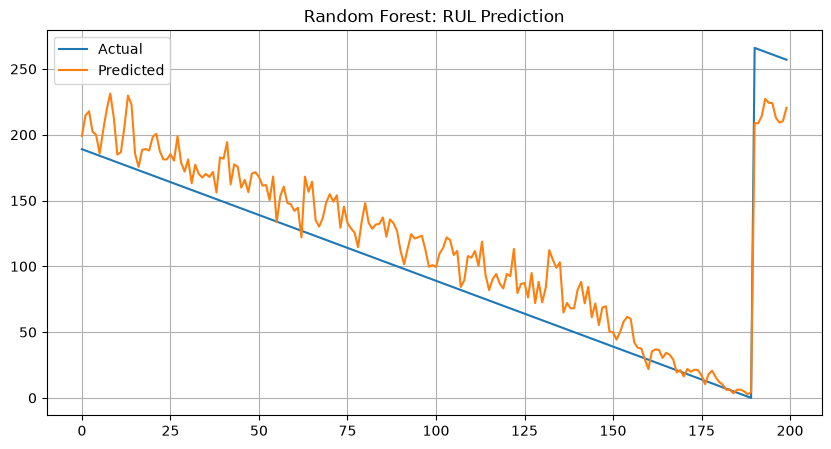

In [25]:
# Plot prediction
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(y_val.values[:200], label="Actual")
plt.plot(y_pred_val[:200], label="Predicted")
plt.title("Random Forest: RUL Prediction")
plt.legend()
plt.grid()
plt.show()

Model overpredicts

### Hyperparameter tuning with Optuna

In [26]:
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

/home/adamtay/miniforge3/envs/jabil/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [27]:
# Hyperparameter tuning random forest
besr_rf = None
best_rmse = None

def rf_objective(trial):
    global besr_rf, best_rmse

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 5, 100),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical(
            "max_features", ["sqrt", "log2", 0.5, 0.8, None]
        ),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "random_state": 42,
        "n_jobs": -1
    }

    model = RandomForestRegressor(**params)
    model.fit(X_train, y_train)

    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))

    if best_rmse is None or rmse < best_rmse:
        best_rmse = rmse
        besr_rf = model

    return rmse


In [28]:
study = optuna.create_study(direction="minimize")
study.optimize(rf_objective, n_trials=100)

[I 2026-07-06 23:26:49,048] A new study created in memory with name: no-name-3769e6d8-a719-42af-a268-ffb4dd10d62c


[I 2026-07-06 23:26:49,492] Trial 0 finished with value: 30.531369946555117 and parameters: {'n_estimators': 173, 'max_depth': 22, 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 0 with value: 30.531369946555117.


[I 2026-07-06 23:26:50,356] Trial 1 finished with value: 29.580147747349923 and parameters: {'n_estimators': 596, 'max_depth': 94, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 'log2', 'bootstrap': True}. Best is trial 1 with value: 29.580147747349923.


[I 2026-07-06 23:26:50,930] Trial 2 finished with value: 30.403101506580022 and parameters: {'n_estimators': 200, 'max_depth': 22, 'min_samples_split': 17, 'min_samples_leaf': 4, 'max_features': 0.8, 'bootstrap': True}. Best is trial 1 with value: 29.580147747349923.


[I 2026-07-06 23:26:51,928] Trial 3 finished with value: 29.930820733792377 and parameters: {'n_estimators': 535, 'max_depth': 38, 'min_samples_split': 9, 'min_samples_leaf': 8, 'max_features': 'log2', 'bootstrap': False}. Best is trial 1 with value: 29.580147747349923.


[I 2026-07-06 23:26:53,068] Trial 4 finished with value: 30.77426720849823 and parameters: {'n_estimators': 307, 'max_depth': 21, 'min_samples_split': 15, 'min_samples_leaf': 10, 'max_features': 0.8, 'bootstrap': False}. Best is trial 1 with value: 29.580147747349923.


[I 2026-07-06 23:26:53,740] Trial 5 finished with value: 29.78486144337901 and parameters: {'n_estimators': 425, 'max_depth': 29, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': True}. Best is trial 1 with value: 29.580147747349923.


[I 2026-07-06 23:26:55,109] Trial 6 finished with value: 30.230725208905444 and parameters: {'n_estimators': 595, 'max_depth': 22, 'min_samples_split': 3, 'min_samples_leaf': 8, 'max_features': 0.5, 'bootstrap': False}. Best is trial 1 with value: 29.580147747349923.


[I 2026-07-06 23:26:56,336] Trial 7 finished with value: 30.26662930980519 and parameters: {'n_estimators': 513, 'max_depth': 15, 'min_samples_split': 13, 'min_samples_leaf': 6, 'max_features': 0.8, 'bootstrap': True}. Best is trial 1 with value: 29.580147747349923.


[I 2026-07-06 23:26:56,989] Trial 8 finished with value: 30.271482543649896 and parameters: {'n_estimators': 344, 'max_depth': 21, 'min_samples_split': 12, 'min_samples_leaf': 1, 'max_features': 0.5, 'bootstrap': True}. Best is trial 1 with value: 29.580147747349923.


[I 2026-07-06 23:26:58,598] Trial 9 finished with value: 30.366186106553787 and parameters: {'n_estimators': 501, 'max_depth': 23, 'min_samples_split': 16, 'min_samples_leaf': 7, 'max_features': None, 'bootstrap': True}. Best is trial 1 with value: 29.580147747349923.


[I 2026-07-06 23:26:58,800] Trial 10 finished with value: 29.66755475255255 and parameters: {'n_estimators': 103, 'max_depth': 100, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 'log2', 'bootstrap': True}. Best is trial 1 with value: 29.580147747349923.


[I 2026-07-06 23:27:00,853] Trial 11 finished with value: 29.62922003256313 and parameters: {'n_estimators': 135, 'max_depth': 100, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 'log2', 'bootstrap': True}. Best is trial 1 with value: 29.580147747349923.


[I 2026-07-06 23:27:01,364] Trial 12 finished with value: 29.58750146205818 and parameters: {'n_estimators': 327, 'max_depth': 89, 'min_samples_split': 3, 'min_samples_leaf': 10, 'max_features': 'log2', 'bootstrap': True}. Best is trial 1 with value: 29.580147747349923.


[I 2026-07-06 23:27:01,829] Trial 13 finished with value: 29.616473343477683 and parameters: {'n_estimators': 289, 'max_depth': 79, 'min_samples_split': 2, 'min_samples_leaf': 9, 'max_features': 'log2', 'bootstrap': True}. Best is trial 1 with value: 29.580147747349923.


[I 2026-07-06 23:27:02,451] Trial 14 finished with value: 29.684650522524418 and parameters: {'n_estimators': 406, 'max_depth': 77, 'min_samples_split': 6, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 1 with value: 29.580147747349923.


[I 2026-07-06 23:27:03,186] Trial 15 finished with value: 30.33263966357815 and parameters: {'n_estimators': 232, 'max_depth': 79, 'min_samples_split': 5, 'min_samples_leaf': 9, 'max_features': None, 'bootstrap': True}. Best is trial 1 with value: 29.580147747349923.


[I 2026-07-06 23:27:03,882] Trial 16 finished with value: 29.77440384460044 and parameters: {'n_estimators': 442, 'max_depth': 61, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': 'log2', 'bootstrap': True}. Best is trial 1 with value: 29.580147747349923.


[I 2026-07-06 23:27:04,770] Trial 17 finished with value: 29.610567274531522 and parameters: {'n_estimators': 594, 'max_depth': 91, 'min_samples_split': 11, 'min_samples_leaf': 9, 'max_features': 'log2', 'bootstrap': True}. Best is trial 1 with value: 29.580147747349923.


[I 2026-07-06 23:27:05,485] Trial 18 finished with value: 29.979647886748996 and parameters: {'n_estimators': 362, 'max_depth': 59, 'min_samples_split': 5, 'min_samples_leaf': 7, 'max_features': 'log2', 'bootstrap': False}. Best is trial 1 with value: 29.580147747349923.


[I 2026-07-06 23:27:05,907] Trial 19 finished with value: 29.595768745197194 and parameters: {'n_estimators': 267, 'max_depth': 67, 'min_samples_split': 7, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 1 with value: 29.580147747349923.


[I 2026-07-06 23:27:07,239] Trial 20 finished with value: 30.325063784271727 and parameters: {'n_estimators': 466, 'max_depth': 88, 'min_samples_split': 3, 'min_samples_leaf': 9, 'max_features': None, 'bootstrap': True}. Best is trial 1 with value: 29.580147747349923.


[I 2026-07-06 23:27:07,650] Trial 21 finished with value: 29.591051714373858 and parameters: {'n_estimators': 253, 'max_depth': 63, 'min_samples_split': 8, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 1 with value: 29.580147747349923.


[I 2026-07-06 23:27:08,192] Trial 22 finished with value: 29.59472834940393 and parameters: {'n_estimators': 362, 'max_depth': 47, 'min_samples_split': 8, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 1 with value: 29.580147747349923.


[I 2026-07-06 23:27:08,593] Trial 23 finished with value: 29.629819498905416 and parameters: {'n_estimators': 237, 'max_depth': 88, 'min_samples_split': 11, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 1 with value: 29.580147747349923.


[I 2026-07-06 23:27:09,135] Trial 24 finished with value: 29.868788700214548 and parameters: {'n_estimators': 315, 'max_depth': 72, 'min_samples_split': 14, 'min_samples_leaf': 8, 'max_features': 0.5, 'bootstrap': True}. Best is trial 1 with value: 29.580147747349923.


[I 2026-07-06 23:27:09,461] Trial 25 finished with value: 29.619111551341494 and parameters: {'n_estimators': 183, 'max_depth': 54, 'min_samples_split': 4, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 1 with value: 29.580147747349923.


[I 2026-07-06 23:27:10,538] Trial 26 finished with value: 29.98848924294698 and parameters: {'n_estimators': 555, 'max_depth': 87, 'min_samples_split': 10, 'min_samples_leaf': 7, 'max_features': 'log2', 'bootstrap': False}. Best is trial 1 with value: 29.580147747349923.


[I 2026-07-06 23:27:10,921] Trial 27 finished with value: 29.642154968467292 and parameters: {'n_estimators': 228, 'max_depth': 95, 'min_samples_split': 7, 'min_samples_leaf': 9, 'max_features': 'log2', 'bootstrap': True}. Best is trial 1 with value: 29.580147747349923.


[I 2026-07-06 23:27:11,512] Trial 28 finished with value: 29.58506823882933 and parameters: {'n_estimators': 392, 'max_depth': 43, 'min_samples_split': 12, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 1 with value: 29.580147747349923.


[I 2026-07-06 23:27:12,253] Trial 29 finished with value: 29.94692948529528 and parameters: {'n_estimators': 398, 'max_depth': 45, 'min_samples_split': 18, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 1 with value: 29.580147747349923.


[I 2026-07-06 23:27:13,540] Trial 30 finished with value: 30.45777167895846 and parameters: {'n_estimators': 475, 'max_depth': 83, 'min_samples_split': 13, 'min_samples_leaf': 2, 'max_features': 0.8, 'bootstrap': True}. Best is trial 1 with value: 29.580147747349923.


[I 2026-07-06 23:27:13,984] Trial 31 finished with value: 29.595152208967107 and parameters: {'n_estimators': 275, 'max_depth': 35, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 1 with value: 29.580147747349923.


[I 2026-07-06 23:27:14,423] Trial 32 finished with value: 29.588155938217383 and parameters: {'n_estimators': 321, 'max_depth': 6, 'min_samples_split': 12, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 1 with value: 29.580147747349923.


[I 2026-07-06 23:27:14,884] Trial 33 finished with value: 29.429580282162657 and parameters: {'n_estimators': 331, 'max_depth': 9, 'min_samples_split': 14, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 33 with value: 29.429580282162657.


[I 2026-07-06 23:27:15,429] Trial 34 finished with value: 29.521464548233013 and parameters: {'n_estimators': 367, 'max_depth': 11, 'min_samples_split': 15, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 33 with value: 29.429580282162657.


[I 2026-07-06 23:27:15,873] Trial 35 finished with value: 30.236052852606672 and parameters: {'n_estimators': 393, 'max_depth': 5, 'min_samples_split': 15, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 33 with value: 29.429580282162657.


[I 2026-07-06 23:27:16,445] Trial 36 finished with value: 29.633381143231503 and parameters: {'n_estimators': 373, 'max_depth': 14, 'min_samples_split': 17, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 33 with value: 29.429580282162657.


[I 2026-07-06 23:27:17,095] Trial 37 finished with value: 29.541041981298203 and parameters: {'n_estimators': 448, 'max_depth': 11, 'min_samples_split': 14, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 33 with value: 29.429580282162657.


[I 2026-07-06 23:27:18,932] Trial 38 finished with value: 30.60114954359546 and parameters: {'n_estimators': 560, 'max_depth': 12, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 0.8, 'bootstrap': False}. Best is trial 33 with value: 29.429580282162657.


[I 2026-07-06 23:27:19,662] Trial 39 finished with value: 29.91802655355837 and parameters: {'n_estimators': 428, 'max_depth': 27, 'min_samples_split': 18, 'min_samples_leaf': 6, 'max_features': 0.5, 'bootstrap': True}. Best is trial 33 with value: 29.429580282162657.


[I 2026-07-06 23:27:20,371] Trial 40 finished with value: 29.495038325814612 and parameters: {'n_estimators': 503, 'max_depth': 10, 'min_samples_split': 14, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 33 with value: 29.429580282162657.


[I 2026-07-06 23:27:21,095] Trial 41 finished with value: 29.498032422807796 and parameters: {'n_estimators': 516, 'max_depth': 10, 'min_samples_split': 14, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 33 with value: 29.429580282162657.


[I 2026-07-06 23:27:21,800] Trial 42 finished with value: 29.486030029449054 and parameters: {'n_estimators': 505, 'max_depth': 10, 'min_samples_split': 14, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 33 with value: 29.429580282162657.


[I 2026-07-06 23:27:22,605] Trial 43 finished with value: 29.82791376160018 and parameters: {'n_estimators': 513, 'max_depth': 17, 'min_samples_split': 16, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 33 with value: 29.429580282162657.


[I 2026-07-06 23:27:23,241] Trial 44 finished with value: 29.401413977963433 and parameters: {'n_estimators': 483, 'max_depth': 9, 'min_samples_split': 14, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 44 with value: 29.401413977963433.


[I 2026-07-06 23:27:23,998] Trial 45 finished with value: 29.788650670577223 and parameters: {'n_estimators': 486, 'max_depth': 18, 'min_samples_split': 13, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 44 with value: 29.401413977963433.


[I 2026-07-06 23:27:24,854] Trial 46 finished with value: 29.830801195893617 and parameters: {'n_estimators': 535, 'max_depth': 27, 'min_samples_split': 14, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 44 with value: 29.401413977963433.


[I 2026-07-06 23:27:25,548] Trial 47 finished with value: 29.36878297507981 and parameters: {'n_estimators': 529, 'max_depth': 8, 'min_samples_split': 16, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:26,814] Trial 48 finished with value: 29.925730174264608 and parameters: {'n_estimators': 571, 'max_depth': 8, 'min_samples_split': 16, 'min_samples_leaf': 3, 'max_features': None, 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:27,646] Trial 49 finished with value: 29.704257615305984 and parameters: {'n_estimators': 536, 'max_depth': 19, 'min_samples_split': 17, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:28,888] Trial 50 finished with value: 30.496182246975742 and parameters: {'n_estimators': 491, 'max_depth': 24, 'min_samples_split': 19, 'min_samples_leaf': 2, 'max_features': 0.5, 'bootstrap': False}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:29,574] Trial 51 finished with value: 29.426502286740106 and parameters: {'n_estimators': 506, 'max_depth': 9, 'min_samples_split': 13, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:30,163] Trial 52 finished with value: 30.042386463787757 and parameters: {'n_estimators': 461, 'max_depth': 5, 'min_samples_split': 13, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:32,819] Trial 53 finished with value: 29.72482508078106 and parameters: {'n_estimators': 518, 'max_depth': 14, 'min_samples_split': 12, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:33,716] Trial 54 finished with value: 29.86797059407934 and parameters: {'n_estimators': 574, 'max_depth': 32, 'min_samples_split': 16, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:34,736] Trial 55 finished with value: 29.910388115725873 and parameters: {'n_estimators': 500, 'max_depth': 9, 'min_samples_split': 13, 'min_samples_leaf': 3, 'max_features': 0.8, 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:35,404] Trial 56 finished with value: 29.73426361882334 and parameters: {'n_estimators': 421, 'max_depth': 15, 'min_samples_split': 17, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:37,077] Trial 57 finished with value: 30.492072030427064 and parameters: {'n_estimators': 540, 'max_depth': 20, 'min_samples_split': 11, 'min_samples_leaf': 5, 'max_features': None, 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:37,983] Trial 58 finished with value: 29.909931145759597 and parameters: {'n_estimators': 596, 'max_depth': 16, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:38,617] Trial 59 finished with value: 29.37237430127546 and parameters: {'n_estimators': 479, 'max_depth': 8, 'min_samples_split': 14, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:39,322] Trial 60 finished with value: 29.687259241656626 and parameters: {'n_estimators': 450, 'max_depth': 23, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:39,984] Trial 61 finished with value: 29.369877354896815 and parameters: {'n_estimators': 474, 'max_depth': 8, 'min_samples_split': 14, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:40,657] Trial 62 finished with value: 29.373426450557112 and parameters: {'n_estimators': 476, 'max_depth': 8, 'min_samples_split': 13, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:41,295] Trial 63 finished with value: 29.379265320571072 and parameters: {'n_estimators': 477, 'max_depth': 7, 'min_samples_split': 13, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:41,893] Trial 64 finished with value: 30.035620639851228 and parameters: {'n_estimators': 476, 'max_depth': 5, 'min_samples_split': 11, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:42,562] Trial 65 finished with value: 29.686783067794458 and parameters: {'n_estimators': 436, 'max_depth': 13, 'min_samples_split': 12, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:43,196] Trial 66 finished with value: 29.45715793422101 and parameters: {'n_estimators': 460, 'max_depth': 7, 'min_samples_split': 12, 'min_samples_leaf': 4, 'max_features': 0.5, 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:43,963] Trial 67 finished with value: 29.81563821189765 and parameters: {'n_estimators': 486, 'max_depth': 17, 'min_samples_split': 13, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:45,623] Trial 68 finished with value: 30.797909257712327 and parameters: {'n_estimators': 472, 'max_depth': 13, 'min_samples_split': 13, 'min_samples_leaf': 4, 'max_features': 0.8, 'bootstrap': False}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:46,532] Trial 69 finished with value: 29.905110821670746 and parameters: {'n_estimators': 419, 'max_depth': 8, 'min_samples_split': 11, 'min_samples_leaf': 5, 'max_features': None, 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:47,336] Trial 70 finished with value: 29.744581335414775 and parameters: {'n_estimators': 524, 'max_depth': 21, 'min_samples_split': 16, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:47,854] Trial 71 finished with value: 29.43030706629957 and parameters: {'n_estimators': 337, 'max_depth': 7, 'min_samples_split': 14, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:48,549] Trial 72 finished with value: 30.022558067842287 and parameters: {'n_estimators': 549, 'max_depth': 5, 'min_samples_split': 15, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:49,302] Trial 73 finished with value: 29.692711870180894 and parameters: {'n_estimators': 491, 'max_depth': 12, 'min_samples_split': 13, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:49,522] Trial 74 finished with value: 29.430199337563238 and parameters: {'n_estimators': 128, 'max_depth': 8, 'min_samples_split': 15, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:50,236] Trial 75 finished with value: 29.72670248860546 and parameters: {'n_estimators': 442, 'max_depth': 15, 'min_samples_split': 14, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:50,983] Trial 76 finished with value: 29.480900678185375 and parameters: {'n_estimators': 523, 'max_depth': 10, 'min_samples_split': 12, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:51,470] Trial 77 finished with value: 29.73351558071666 and parameters: {'n_estimators': 299, 'max_depth': 13, 'min_samples_split': 16, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:51,924] Trial 78 finished with value: 30.120852648424037 and parameters: {'n_estimators': 212, 'max_depth': 18, 'min_samples_split': 14, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:52,804] Trial 79 finished with value: 29.740664116525092 and parameters: {'n_estimators': 581, 'max_depth': 25, 'min_samples_split': 13, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:53,368] Trial 80 finished with value: 29.386438453703185 and parameters: {'n_estimators': 408, 'max_depth': 8, 'min_samples_split': 18, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:53,970] Trial 81 finished with value: 29.396243907599523 and parameters: {'n_estimators': 456, 'max_depth': 8, 'min_samples_split': 18, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:54,480] Trial 82 finished with value: 30.0572282826828 and parameters: {'n_estimators': 406, 'max_depth': 5, 'min_samples_split': 19, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:55,123] Trial 83 finished with value: 29.3947715573723 and parameters: {'n_estimators': 480, 'max_depth': 8, 'min_samples_split': 18, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:55,790] Trial 84 finished with value: 29.584314816811506 and parameters: {'n_estimators': 449, 'max_depth': 11, 'min_samples_split': 18, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:56,517] Trial 85 finished with value: 29.72321476434912 and parameters: {'n_estimators': 459, 'max_depth': 15, 'min_samples_split': 19, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:57,045] Trial 86 finished with value: 29.424657550503987 and parameters: {'n_estimators': 380, 'max_depth': 7, 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:57,776] Trial 87 finished with value: 29.605537821841033 and parameters: {'n_estimators': 485, 'max_depth': 12, 'min_samples_split': 18, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:58,486] Trial 88 finished with value: 29.866593119524442 and parameters: {'n_estimators': 431, 'max_depth': 20, 'min_samples_split': 19, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:59,122] Trial 89 finished with value: 29.404949438536505 and parameters: {'n_estimators': 472, 'max_depth': 7, 'min_samples_split': 17, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:27:59,805] Trial 90 finished with value: 29.773538362940023 and parameters: {'n_estimators': 407, 'max_depth': 16, 'min_samples_split': 18, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:28:00,446] Trial 91 finished with value: 29.40530029546482 and parameters: {'n_estimators': 473, 'max_depth': 7, 'min_samples_split': 17, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:28:01,145] Trial 92 finished with value: 29.443799733507607 and parameters: {'n_estimators': 495, 'max_depth': 9, 'min_samples_split': 17, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:28:01,850] Trial 93 finished with value: 29.64208140062497 and parameters: {'n_estimators': 457, 'max_depth': 11, 'min_samples_split': 16, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:28:02,468] Trial 94 finished with value: 30.03982338981129 and parameters: {'n_estimators': 475, 'max_depth': 5, 'min_samples_split': 18, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:28:03,746] Trial 95 finished with value: 29.405759493221794 and parameters: {'n_estimators': 438, 'max_depth': 8, 'min_samples_split': 17, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:28:04,524] Trial 96 finished with value: 29.871529046917814 and parameters: {'n_estimators': 418, 'max_depth': 13, 'min_samples_split': 19, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': False}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:28:05,235] Trial 97 finished with value: 29.477131132915133 and parameters: {'n_estimators': 511, 'max_depth': 10, 'min_samples_split': 20, 'min_samples_leaf': 6, 'max_features': 'log2', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:28:05,910] Trial 98 finished with value: 29.48774460739349 and parameters: {'n_estimators': 481, 'max_depth': 7, 'min_samples_split': 18, 'min_samples_leaf': 2, 'max_features': 0.5, 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


[I 2026-07-06 23:28:06,474] Trial 99 finished with value: 29.74986497738473 and parameters: {'n_estimators': 353, 'max_depth': 16, 'min_samples_split': 16, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': True}. Best is trial 47 with value: 29.36878297507981.


In [29]:
print("Best RMSE:", study.best_value)
print("Best params:", study.best_params)

Best RMSE: 29.36878297507981
Best params: {'n_estimators': 529, 'max_depth': 8, 'min_samples_split': 16, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}


In [30]:
y_pred_train = besr_rf.predict(X_train)
y_pred_val = besr_rf.predict(X_val)
evaluate(y_train, y_pred_train, "Train")
evaluate(y_val, y_pred_val, "Validation")


Train Performance:
RMSE: 36.6781
MAE : 26.1722
R2  : 0.7187

Validation Performance:
RMSE: 29.3688
MAE : 22.7863
R2  : 0.7967


In [31]:
import xgboost as xgb

best_xg = None
xgb_best_rmse = None


def xgb_objective(trial):
    global best_xg, xgb_best_rmse

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
        "random_state": 42,
        "n_jobs": -1,
        "objective": "reg:squarederror",
    }

    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train)

    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))

    if xgb_best_rmse is None or rmse < xgb_best_rmse:
        xgb_best_rmse = rmse
        best_xg = model

    return rmse


In [32]:
study = optuna.create_study(direction="minimize")
study.optimize(xgb_objective, n_trials=100)

[I 2026-07-06 23:28:06,705] A new study created in memory with name: no-name-88e5be5b-e9e1-49c2-b9ef-039cefd56548


[I 2026-07-06 23:28:06,990] Trial 0 finished with value: 29.81910079081286 and parameters: {'n_estimators': 161, 'max_depth': 3, 'learning_rate': 0.16314258390257827, 'subsample': 0.7385839403697892, 'colsample_bytree': 0.5289853512636873, 'min_child_weight': 6, 'gamma': 3.90491880892342, 'reg_alpha': 4.912879077197258, 'reg_lambda': 1.440423352928895}. Best is trial 0 with value: 29.81910079081286.


[I 2026-07-06 23:28:07,284] Trial 1 finished with value: 31.246314235767272 and parameters: {'n_estimators': 149, 'max_depth': 9, 'learning_rate': 0.08669848083831855, 'subsample': 0.9017091007406436, 'colsample_bytree': 0.5390072245933459, 'min_child_weight': 5, 'gamma': 1.1220955984757852, 'reg_alpha': 4.124854293185795, 'reg_lambda': 1.0484517521176646}. Best is trial 0 with value: 29.81910079081286.


[I 2026-07-06 23:28:07,496] Trial 2 finished with value: 31.361891481616468 and parameters: {'n_estimators': 175, 'max_depth': 7, 'learning_rate': 0.10549818962238545, 'subsample': 0.5792601236771251, 'colsample_bytree': 0.6145644079041666, 'min_child_weight': 8, 'gamma': 3.0518981602060573, 'reg_alpha': 1.1222879904918432, 'reg_lambda': 2.8546025040934353}. Best is trial 0 with value: 29.81910079081286.


[I 2026-07-06 23:28:08,047] Trial 3 finished with value: 31.194598351454914 and parameters: {'n_estimators': 404, 'max_depth': 7, 'learning_rate': 0.04733918353811318, 'subsample': 0.6048215288514598, 'colsample_bytree': 0.8187148458918279, 'min_child_weight': 7, 'gamma': 4.986833220876007, 'reg_alpha': 4.352382689121292, 'reg_lambda': 0.9630913250500955}. Best is trial 0 with value: 29.81910079081286.


[I 2026-07-06 23:28:08,182] Trial 4 finished with value: 29.844472954266905 and parameters: {'n_estimators': 153, 'max_depth': 4, 'learning_rate': 0.11012514246922729, 'subsample': 0.7592352674969206, 'colsample_bytree': 0.7165644870834693, 'min_child_weight': 9, 'gamma': 1.350725183063037, 'reg_alpha': 1.3727503501870486, 'reg_lambda': 0.3632725316303498}. Best is trial 0 with value: 29.81910079081286.


[I 2026-07-06 23:28:08,802] Trial 5 finished with value: 30.764438619837517 and parameters: {'n_estimators': 211, 'max_depth': 8, 'learning_rate': 0.053097613611888375, 'subsample': 0.7998676742591173, 'colsample_bytree': 0.9345031036095532, 'min_child_weight': 2, 'gamma': 2.3475506969073274, 'reg_alpha': 4.277269306621366, 'reg_lambda': 3.3114650910116437}. Best is trial 0 with value: 29.81910079081286.


[I 2026-07-06 23:28:09,141] Trial 6 finished with value: 31.326474785090923 and parameters: {'n_estimators': 240, 'max_depth': 6, 'learning_rate': 0.11024804694583143, 'subsample': 0.5008175984110632, 'colsample_bytree': 0.5868353655899896, 'min_child_weight': 8, 'gamma': 4.630032129945859, 'reg_alpha': 0.096220997290144, 'reg_lambda': 4.381546105554254}. Best is trial 0 with value: 29.81910079081286.


[I 2026-07-06 23:28:09,746] Trial 7 finished with value: 31.760155202644928 and parameters: {'n_estimators': 385, 'max_depth': 6, 'learning_rate': 0.09366349104542938, 'subsample': 0.5895612616937991, 'colsample_bytree': 0.7134157937563352, 'min_child_weight': 3, 'gamma': 2.215874753046962, 'reg_alpha': 0.7629080521168036, 'reg_lambda': 3.4526568354095435}. Best is trial 0 with value: 29.81910079081286.


[I 2026-07-06 23:28:09,946] Trial 8 finished with value: 29.700405295332775 and parameters: {'n_estimators': 123, 'max_depth': 4, 'learning_rate': 0.03062173598760838, 'subsample': 0.7288423864615341, 'colsample_bytree': 0.8981184893293181, 'min_child_weight': 6, 'gamma': 4.955230884613211, 'reg_alpha': 2.1697844771931174, 'reg_lambda': 1.5808950133634225}. Best is trial 8 with value: 29.700405295332775.


[I 2026-07-06 23:28:10,154] Trial 9 finished with value: 30.923747140458758 and parameters: {'n_estimators': 135, 'max_depth': 7, 'learning_rate': 0.1400452668352943, 'subsample': 0.9221604270935029, 'colsample_bytree': 0.5051502350355881, 'min_child_weight': 1, 'gamma': 4.189049150094549, 'reg_alpha': 0.16170321603366067, 'reg_lambda': 1.365956625234207}. Best is trial 8 with value: 29.700405295332775.


[I 2026-07-06 23:28:11,570] Trial 10 finished with value: 30.36352925289493 and parameters: {'n_estimators': 331, 'max_depth': 10, 'learning_rate': 0.01111501609889455, 'subsample': 0.9853042262403366, 'colsample_bytree': 0.99951875275415, 'min_child_weight': 10, 'gamma': 0.29711007232106645, 'reg_alpha': 2.6397684700102064, 'reg_lambda': 4.866016690930059}. Best is trial 8 with value: 29.700405295332775.


[I 2026-07-06 23:28:11,897] Trial 11 finished with value: 31.27784599204913 and parameters: {'n_estimators': 269, 'max_depth': 3, 'learning_rate': 0.2638939050281152, 'subsample': 0.7299945246980769, 'colsample_bytree': 0.8496145230025169, 'min_child_weight': 5, 'gamma': 3.7421343692431823, 'reg_alpha': 2.9864736505475085, 'reg_lambda': 2.0783412257615255}. Best is trial 8 with value: 29.700405295332775.


[I 2026-07-06 23:28:11,995] Trial 12 finished with value: 31.509561692085526 and parameters: {'n_estimators': 103, 'max_depth': 4, 'learning_rate': 0.017951722985495234, 'subsample': 0.6848820546354312, 'colsample_bytree': 0.7008298029618373, 'min_child_weight': 5, 'gamma': 3.6524325984526804, 'reg_alpha': 2.6295705495784594, 'reg_lambda': 2.052581108920814}. Best is trial 8 with value: 29.700405295332775.


[I 2026-07-06 23:28:12,275] Trial 13 finished with value: 29.53900154549384 and parameters: {'n_estimators': 468, 'max_depth': 3, 'learning_rate': 0.027726626328857, 'subsample': 0.8305941797270009, 'colsample_bytree': 0.7908586062604528, 'min_child_weight': 6, 'gamma': 4.2636021638824, 'reg_alpha': 3.3746391034468166, 'reg_lambda': 0.03474297042109287}. Best is trial 13 with value: 29.53900154549384.


[I 2026-07-06 23:28:12,762] Trial 14 finished with value: 29.991727578526238 and parameters: {'n_estimators': 496, 'max_depth': 5, 'learning_rate': 0.03177968494332513, 'subsample': 0.8480155652893914, 'colsample_bytree': 0.8255358396579167, 'min_child_weight': 4, 'gamma': 4.4790771489563275, 'reg_alpha': 1.9858703319813062, 'reg_lambda': 0.14799819763501088}. Best is trial 13 with value: 29.53900154549384.


[I 2026-07-06 23:28:13,128] Trial 15 finished with value: 29.68869343818293 and parameters: {'n_estimators': 456, 'max_depth': 4, 'learning_rate': 0.02419186479379326, 'subsample': 0.8329060313952875, 'colsample_bytree': 0.8997591852145658, 'min_child_weight': 7, 'gamma': 4.977939686216523, 'reg_alpha': 3.471261477566757, 'reg_lambda': 2.1122380106546466}. Best is trial 13 with value: 29.53900154549384.


[I 2026-07-06 23:28:13,435] Trial 16 finished with value: 29.369731284481585 and parameters: {'n_estimators': 495, 'max_depth': 3, 'learning_rate': 0.01668919866484182, 'subsample': 0.8338174884452826, 'colsample_bytree': 0.7749178911512167, 'min_child_weight': 7, 'gamma': 3.080374429543177, 'reg_alpha': 3.4650483368685636, 'reg_lambda': 2.5402606532898524}. Best is trial 16 with value: 29.369731284481585.


[I 2026-07-06 23:28:13,690] Trial 17 finished with value: 29.397768976587002 and parameters: {'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.011591361067631208, 'subsample': 0.9123380590456744, 'colsample_bytree': 0.7654867727435941, 'min_child_weight': 10, 'gamma': 3.0295126335840163, 'reg_alpha': 3.4704185571442774, 'reg_lambda': 2.8009864273818597}. Best is trial 16 with value: 29.369731284481585.


[I 2026-07-06 23:28:14,062] Trial 18 finished with value: 29.538466380192286 and parameters: {'n_estimators': 424, 'max_depth': 5, 'learning_rate': 0.012617795830542159, 'subsample': 0.9988602252374102, 'colsample_bytree': 0.7567777303552342, 'min_child_weight': 10, 'gamma': 3.00174525785374, 'reg_alpha': 3.718188454488048, 'reg_lambda': 2.825934318644214}. Best is trial 16 with value: 29.369731284481585.


[I 2026-07-06 23:28:14,231] Trial 19 finished with value: 29.289998151232766 and parameters: {'n_estimators': 347, 'max_depth': 3, 'learning_rate': 0.015263407271146954, 'subsample': 0.910756555521089, 'colsample_bytree': 0.6526955577780083, 'min_child_weight': 9, 'gamma': 3.0673125162599733, 'reg_alpha': 3.071732522680681, 'reg_lambda': 3.9014677950773065}. Best is trial 19 with value: 29.289998151232766.


[I 2026-07-06 23:28:14,497] Trial 20 finished with value: 29.440794418231356 and parameters: {'n_estimators': 343, 'max_depth': 5, 'learning_rate': 0.016065926800181783, 'subsample': 0.9479689978572853, 'colsample_bytree': 0.6457562911748471, 'min_child_weight': 8, 'gamma': 2.2236592517963625, 'reg_alpha': 2.179641845936653, 'reg_lambda': 4.106709615706181}. Best is trial 19 with value: 29.289998151232766.


[I 2026-07-06 23:28:14,771] Trial 21 finished with value: 29.399570010407892 and parameters: {'n_estimators': 499, 'max_depth': 3, 'learning_rate': 0.018901737469681195, 'subsample': 0.8850400280533546, 'colsample_bytree': 0.6716260546373589, 'min_child_weight': 10, 'gamma': 3.1042680836569136, 'reg_alpha': 3.0440194398539036, 'reg_lambda': 3.6481915067795168}. Best is trial 19 with value: 29.289998151232766.


[I 2026-07-06 23:28:14,988] Trial 22 finished with value: 29.520738456607713 and parameters: {'n_estimators': 348, 'max_depth': 3, 'learning_rate': 0.010645622105375329, 'subsample': 0.8842401648716494, 'colsample_bytree': 0.7578121220886994, 'min_child_weight': 9, 'gamma': 2.673689515355465, 'reg_alpha': 3.7776126154679606, 'reg_lambda': 2.7409279708450027}. Best is trial 19 with value: 29.289998151232766.


[I 2026-07-06 23:28:15,177] Trial 23 finished with value: 29.437336202437077 and parameters: {'n_estimators': 291, 'max_depth': 4, 'learning_rate': 0.01513538153686388, 'subsample': 0.9509359933507335, 'colsample_bytree': 0.7610240317540244, 'min_child_weight': 9, 'gamma': 1.774243189349344, 'reg_alpha': 4.93630613807325, 'reg_lambda': 2.5154268642925195}. Best is trial 19 with value: 29.289998151232766.


[I 2026-07-06 23:28:15,401] Trial 24 finished with value: 29.35582506645029 and parameters: {'n_estimators': 440, 'max_depth': 3, 'learning_rate': 0.021791057973549466, 'subsample': 0.7897980020026312, 'colsample_bytree': 0.5934196645045753, 'min_child_weight': 9, 'gamma': 3.397618317264302, 'reg_alpha': 3.1076309692781523, 'reg_lambda': 3.9801736001842727}. Best is trial 19 with value: 29.289998151232766.


[I 2026-07-06 23:28:15,691] Trial 25 finished with value: 29.476668102116694 and parameters: {'n_estimators': 436, 'max_depth': 4, 'learning_rate': 0.022380873050841566, 'subsample': 0.789016410635769, 'colsample_bytree': 0.599608242122132, 'min_child_weight': 7, 'gamma': 3.4194852562098026, 'reg_alpha': 2.8524303456907325, 'reg_lambda': 3.950056149390127}. Best is trial 19 with value: 29.289998151232766.


[I 2026-07-06 23:28:16,039] Trial 26 finished with value: 29.99485226016916 and parameters: {'n_estimators': 379, 'max_depth': 5, 'learning_rate': 0.04461948450836225, 'subsample': 0.6723517287498411, 'colsample_bytree': 0.5741517419104428, 'min_child_weight': 8, 'gamma': 2.5314971218515714, 'reg_alpha': 1.7803556271836223, 'reg_lambda': 4.904402421325994}. Best is trial 19 with value: 29.289998151232766.


[I 2026-07-06 23:28:16,285] Trial 27 finished with value: 29.480806992974788 and parameters: {'n_estimators': 462, 'max_depth': 3, 'learning_rate': 0.040914866201347995, 'subsample': 0.8675644419648775, 'colsample_bytree': 0.6521902942319937, 'min_child_weight': 9, 'gamma': 3.419341546684462, 'reg_alpha': 2.5437772774222878, 'reg_lambda': 4.275125655605969}. Best is trial 19 with value: 29.289998151232766.


[I 2026-07-06 23:28:16,508] Trial 28 finished with value: 29.784063760702004 and parameters: {'n_estimators': 310, 'max_depth': 4, 'learning_rate': 0.0634103254470198, 'subsample': 0.7961644096410869, 'colsample_bytree': 0.6245255696011731, 'min_child_weight': 7, 'gamma': 2.7654231572220644, 'reg_alpha': 3.1551307703008997, 'reg_lambda': 3.1935433332358385}. Best is trial 19 with value: 29.289998151232766.


[I 2026-07-06 23:28:17,002] Trial 29 finished with value: 29.1993940734703 and parameters: {'n_estimators': 372, 'max_depth': 3, 'learning_rate': 0.021466418957006708, 'subsample': 0.6930856921450539, 'colsample_bytree': 0.553723110278657, 'min_child_weight': 9, 'gamma': 3.980156015456863, 'reg_alpha': 3.9206263525142098, 'reg_lambda': 3.785284311555261}. Best is trial 29 with value: 29.1993940734703.


[I 2026-07-06 23:28:17,191] Trial 30 finished with value: 29.19778346179777 and parameters: {'n_estimators': 375, 'max_depth': 3, 'learning_rate': 0.022134582163150535, 'subsample': 0.6804056080956772, 'colsample_bytree': 0.5464706679778154, 'min_child_weight': 9, 'gamma': 3.828719145542343, 'reg_alpha': 4.50268246122117, 'reg_lambda': 4.540447109569163}. Best is trial 30 with value: 29.19778346179777.


[I 2026-07-06 23:28:17,421] Trial 31 finished with value: 29.201818707407806 and parameters: {'n_estimators': 369, 'max_depth': 3, 'learning_rate': 0.02168407826427218, 'subsample': 0.6629588478385464, 'colsample_bytree': 0.541094491946242, 'min_child_weight': 9, 'gamma': 4.0115981379533325, 'reg_alpha': 4.603362439446734, 'reg_lambda': 4.541021868564631}. Best is trial 30 with value: 29.19778346179777.


[I 2026-07-06 23:28:17,631] Trial 32 finished with value: 29.303302419946522 and parameters: {'n_estimators': 374, 'max_depth': 3, 'learning_rate': 0.034827107225665975, 'subsample': 0.6603084079250846, 'colsample_bytree': 0.5424345282794237, 'min_child_weight': 9, 'gamma': 4.026902445238023, 'reg_alpha': 4.607523125645597, 'reg_lambda': 4.617136449782508}. Best is trial 30 with value: 29.19778346179777.


[I 2026-07-06 23:28:17,928] Trial 33 finished with value: 29.202300474917106 and parameters: {'n_estimators': 360, 'max_depth': 4, 'learning_rate': 0.0138375168818038, 'subsample': 0.6308930211520274, 'colsample_bytree': 0.5476952241831423, 'min_child_weight': 8, 'gamma': 3.8687358952961683, 'reg_alpha': 4.679511109908154, 'reg_lambda': 3.6860366837431826}. Best is trial 30 with value: 29.19778346179777.


[I 2026-07-06 23:28:18,197] Trial 34 finished with value: 29.35860683701044 and parameters: {'n_estimators': 407, 'max_depth': 4, 'learning_rate': 0.02414055088223488, 'subsample': 0.6292681932427963, 'colsample_bytree': 0.5499944107785764, 'min_child_weight': 8, 'gamma': 3.905298701440209, 'reg_alpha': 4.634460110046662, 'reg_lambda': 4.557958969425139}. Best is trial 30 with value: 29.19778346179777.


[I 2026-07-06 23:28:20,990] Trial 35 finished with value: 29.289674115046502 and parameters: {'n_estimators': 363, 'max_depth': 5, 'learning_rate': 0.013072710885327389, 'subsample': 0.5515767366024246, 'colsample_bytree': 0.5171140652902633, 'min_child_weight': 8, 'gamma': 4.463596017454451, 'reg_alpha': 4.1546014589740565, 'reg_lambda': 3.644490732086988}. Best is trial 30 with value: 29.19778346179777.


[I 2026-07-06 23:28:21,233] Trial 36 finished with value: 29.378367908659637 and parameters: {'n_estimators': 317, 'max_depth': 4, 'learning_rate': 0.019434228888162694, 'subsample': 0.7022413489026476, 'colsample_bytree': 0.5663659855061328, 'min_child_weight': 10, 'gamma': 3.7013692283914885, 'reg_alpha': 4.664929134752667, 'reg_lambda': 4.535388031491091}. Best is trial 30 with value: 29.19778346179777.


[I 2026-07-06 23:28:21,783] Trial 37 finished with value: 30.824247213980648 and parameters: {'n_estimators': 399, 'max_depth': 6, 'learning_rate': 0.06620835994177002, 'subsample': 0.6272344840481028, 'colsample_bytree': 0.5344487216468957, 'min_child_weight': 8, 'gamma': 4.146854858349938, 'reg_alpha': 3.8560388556238716, 'reg_lambda': 3.739596301995006}. Best is trial 30 with value: 29.19778346179777.


[I 2026-07-06 23:28:22,066] Trial 38 finished with value: 29.55492189472212 and parameters: {'n_estimators': 280, 'max_depth': 5, 'learning_rate': 0.03791519759852322, 'subsample': 0.6434332912641686, 'colsample_bytree': 0.5038687645229134, 'min_child_weight': 9, 'gamma': 4.706443938723574, 'reg_alpha': 4.427045198048785, 'reg_lambda': 4.257147768757114}. Best is trial 30 with value: 29.19778346179777.


[I 2026-07-06 23:28:22,446] Trial 39 finished with value: 29.60042122206097 and parameters: {'n_estimators': 405, 'max_depth': 4, 'learning_rate': 0.027311866994163193, 'subsample': 0.5483520906585372, 'colsample_bytree': 0.6200173709785343, 'min_child_weight': 7, 'gamma': 3.856486331721976, 'reg_alpha': 4.042309596742422, 'reg_lambda': 3.171215217107022}. Best is trial 30 with value: 29.19778346179777.


[I 2026-07-06 23:28:23,354] Trial 40 finished with value: 30.127078669207624 and parameters: {'n_estimators': 364, 'max_depth': 9, 'learning_rate': 0.021125192438838727, 'subsample': 0.7064106178688365, 'colsample_bytree': 0.5599288716691515, 'min_child_weight': 8, 'gamma': 4.345496900882994, 'reg_alpha': 4.9057673894914515, 'reg_lambda': 3.4780831664112384}. Best is trial 30 with value: 29.19778346179777.


[I 2026-07-06 23:28:23,828] Trial 41 finished with value: 29.270232677518873 and parameters: {'n_estimators': 366, 'max_depth': 5, 'learning_rate': 0.012902188405703976, 'subsample': 0.5374995780367644, 'colsample_bytree': 0.5243217465604065, 'min_child_weight': 8, 'gamma': 4.578497716263961, 'reg_alpha': 4.156988116970323, 'reg_lambda': 3.6510701871893723}. Best is trial 30 with value: 29.19778346179777.


[I 2026-07-06 23:28:24,280] Trial 42 finished with value: 29.38447839933153 and parameters: {'n_estimators': 317, 'max_depth': 6, 'learning_rate': 0.013629931397387586, 'subsample': 0.5075689001645487, 'colsample_bytree': 0.5303350668043987, 'min_child_weight': 9, 'gamma': 4.654879397482482, 'reg_alpha': 4.356926482806722, 'reg_lambda': 4.762653402396744}. Best is trial 30 with value: 29.19778346179777.


[I 2026-07-06 23:28:24,608] Trial 43 finished with value: 29.30681185648494 and parameters: {'n_estimators': 390, 'max_depth': 3, 'learning_rate': 0.014139379219086848, 'subsample': 0.6003275973285411, 'colsample_bytree': 0.5785264230402487, 'min_child_weight': 10, 'gamma': 4.038327293472406, 'reg_alpha': 4.114977273228709, 'reg_lambda': 4.993250641185676}. Best is trial 30 with value: 29.19778346179777.


[I 2026-07-06 23:28:25,021] Trial 44 finished with value: 29.506156666872084 and parameters: {'n_estimators': 422, 'max_depth': 4, 'learning_rate': 0.026910288077866, 'subsample': 0.566780209568933, 'colsample_bytree': 0.5240215059282991, 'min_child_weight': 8, 'gamma': 3.555671144670394, 'reg_alpha': 4.773460656972878, 'reg_lambda': 4.299534980920203}. Best is trial 30 with value: 29.19778346179777.


[I 2026-07-06 23:28:25,230] Trial 45 finished with value: 30.023474092483557 and parameters: {'n_estimators': 249, 'max_depth': 5, 'learning_rate': 0.010425627833288814, 'subsample': 0.7501542286332362, 'colsample_bytree': 0.6019674702257207, 'min_child_weight': 6, 'gamma': 4.7520984965011355, 'reg_alpha': 4.438779586428881, 'reg_lambda': 3.3547895649425667}. Best is trial 30 with value: 29.19778346179777.


[I 2026-07-06 23:28:25,691] Trial 46 finished with value: 29.701568418248662 and parameters: {'n_estimators': 332, 'max_depth': 7, 'learning_rate': 0.017876783770992482, 'subsample': 0.6992158261307244, 'colsample_bytree': 0.5675550626786338, 'min_child_weight': 8, 'gamma': 0.05668969574960947, 'reg_alpha': 4.015068121426831, 'reg_lambda': 4.110376641814915}. Best is trial 30 with value: 29.19778346179777.


[I 2026-07-06 23:28:25,924] Trial 47 finished with value: 32.21912698312428 and parameters: {'n_estimators': 356, 'max_depth': 4, 'learning_rate': 0.2332055990393009, 'subsample': 0.6183611442121465, 'colsample_bytree': 0.5010654185569993, 'min_child_weight': 7, 'gamma': 4.372598029804323, 'reg_alpha': 4.282209794406531, 'reg_lambda': 3.7768668653558546}. Best is trial 30 with value: 29.19778346179777.


[I 2026-07-06 23:28:26,050] Trial 48 finished with value: 29.191495895503326 and parameters: {'n_estimators': 171, 'max_depth': 3, 'learning_rate': 0.029401692185612924, 'subsample': 0.6563659794566796, 'colsample_bytree': 0.5352803985572174, 'min_child_weight': 1, 'gamma': 4.019262240473227, 'reg_alpha': 3.8713734723753515, 'reg_lambda': 3.1105295497673935}. Best is trial 48 with value: 29.191495895503326.


[I 2026-07-06 23:28:26,170] Trial 49 finished with value: 29.458909204907243 and parameters: {'n_estimators': 197, 'max_depth': 3, 'learning_rate': 0.05650216953005157, 'subsample': 0.6559184375051851, 'colsample_bytree': 0.5566413576652217, 'min_child_weight': 1, 'gamma': 3.9316881595399025, 'reg_alpha': 3.7274085044327228, 'reg_lambda': 4.4656476210475455}. Best is trial 48 with value: 29.191495895503326.


[I 2026-07-06 23:28:26,285] Trial 50 finished with value: 29.285005929069317 and parameters: {'n_estimators': 171, 'max_depth': 3, 'learning_rate': 0.030492270386210826, 'subsample': 0.7254429241986446, 'colsample_bytree': 0.6290125945987131, 'min_child_weight': 3, 'gamma': 0.7228672853664431, 'reg_alpha': 4.564853295050674, 'reg_lambda': 3.228813578060888}. Best is trial 48 with value: 29.191495895503326.


[I 2026-07-06 23:28:26,482] Trial 51 finished with value: 29.193174802993337 and parameters: {'n_estimators': 376, 'max_depth': 3, 'learning_rate': 0.019406595220902077, 'subsample': 0.6769490434033628, 'colsample_bytree': 0.5382770336479694, 'min_child_weight': 2, 'gamma': 4.222588822146877, 'reg_alpha': 3.947531527102051, 'reg_lambda': 3.0943434906368554}. Best is trial 48 with value: 29.191495895503326.


[I 2026-07-06 23:28:26,600] Trial 52 finished with value: 29.163603122219182 and parameters: {'n_estimators': 213, 'max_depth': 3, 'learning_rate': 0.023297762388426988, 'subsample': 0.6704144356650333, 'colsample_bytree': 0.5446583559526548, 'min_child_weight': 2, 'gamma': 4.161414143053442, 'reg_alpha': 4.998429522662258, 'reg_lambda': 2.975513547513125}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:26,716] Trial 53 finished with value: 29.309533723514672 and parameters: {'n_estimators': 196, 'max_depth': 3, 'learning_rate': 0.024926843622833757, 'subsample': 0.6812105429960859, 'colsample_bytree': 0.5869768669542658, 'min_child_weight': 2, 'gamma': 4.222755043419961, 'reg_alpha': 4.992674581587936, 'reg_lambda': 3.0517743845505945}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:26,873] Trial 54 finished with value: 29.256400166178917 and parameters: {'n_estimators': 231, 'max_depth': 3, 'learning_rate': 0.033451828896512735, 'subsample': 0.7182171839736241, 'colsample_bytree': 0.5179590656384415, 'min_child_weight': 1, 'gamma': 3.6128024439547595, 'reg_alpha': 3.588365023206534, 'reg_lambda': 2.5066652816806823}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:26,988] Trial 55 finished with value: 29.512131087870564 and parameters: {'n_estimators': 166, 'max_depth': 3, 'learning_rate': 0.020417979790396525, 'subsample': 0.7672801413264154, 'colsample_bytree': 0.5369246392163909, 'min_child_weight': 2, 'gamma': 4.209139370670868, 'reg_alpha': 3.974618634487403, 'reg_lambda': 2.3330309438512318}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:27,064] Trial 56 finished with value: 29.385216807042195 and parameters: {'n_estimators': 129, 'max_depth': 3, 'learning_rate': 0.029000590242276872, 'subsample': 0.6637911034640214, 'colsample_bytree': 0.608648284526073, 'min_child_weight': 3, 'gamma': 3.317826745089564, 'reg_alpha': 4.811070446435679, 'reg_lambda': 2.951007476060377}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:27,164] Trial 57 finished with value: 30.151880957793807 and parameters: {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.01737503413312218, 'subsample': 0.6902085840674989, 'colsample_bytree': 0.5819047235302132, 'min_child_weight': 4, 'gamma': 3.7604417956815173, 'reg_alpha': 4.430724964059271, 'reg_lambda': 3.5148084544635116}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:27,294] Trial 58 finished with value: 29.33330443409739 and parameters: {'n_estimators': 221, 'max_depth': 3, 'learning_rate': 0.024641654681763707, 'subsample': 0.7440426083305388, 'colsample_bytree': 0.5559873881746733, 'min_child_weight': 2, 'gamma': 4.829141520388808, 'reg_alpha': 3.3418828228425457, 'reg_lambda': 2.6441284462797574}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:27,420] Trial 59 finished with value: 29.254609095325687 and parameters: {'n_estimators': 183, 'max_depth': 4, 'learning_rate': 0.036672938472491444, 'subsample': 0.6487025372585178, 'colsample_bytree': 0.5024434403702337, 'min_child_weight': 1, 'gamma': 4.147226581310294, 'reg_alpha': 3.865855701155465, 'reg_lambda': 1.8429457979632882}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:27,483] Trial 60 finished with value: 30.84691797623893 and parameters: {'n_estimators': 101, 'max_depth': 3, 'learning_rate': 0.02248090466537987, 'subsample': 0.7717120621062804, 'colsample_bytree': 0.9927375683787828, 'min_child_weight': 2, 'gamma': 3.2465772353451774, 'reg_alpha': 3.6340105482467613, 'reg_lambda': 1.0302754827206704}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:27,796] Trial 61 finished with value: 29.280910233487663 and parameters: {'n_estimators': 392, 'max_depth': 4, 'learning_rate': 0.01899335332941477, 'subsample': 0.6090456232171448, 'colsample_bytree': 0.5503216010897037, 'min_child_weight': 3, 'gamma': 3.959674863774341, 'reg_alpha': 4.770220864857917, 'reg_lambda': 2.985922183462339}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:28,017] Trial 62 finished with value: 29.233222518705066 and parameters: {'n_estimators': 299, 'max_depth': 4, 'learning_rate': 0.015407200114780308, 'subsample': 0.58458731731124, 'colsample_bytree': 0.5347805466564157, 'min_child_weight': 1, 'gamma': 3.569619021979387, 'reg_alpha': 4.312008733113312, 'reg_lambda': 4.740780326418131}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:28,225] Trial 63 finished with value: 29.289343823668936 and parameters: {'n_estimators': 332, 'max_depth': 3, 'learning_rate': 0.016526876882563317, 'subsample': 0.6784443086508176, 'colsample_bytree': 0.5864585107666783, 'min_child_weight': 1, 'gamma': 3.767446855090439, 'reg_alpha': 4.541771885676672, 'reg_lambda': 4.114300835427769}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:28,495] Trial 64 finished with value: 29.324377715783992 and parameters: {'n_estimators': 377, 'max_depth': 4, 'learning_rate': 0.01199691211768244, 'subsample': 0.6365057613227256, 'colsample_bytree': 0.5705971518004617, 'min_child_weight': 5, 'gamma': 4.492250675767025, 'reg_alpha': 4.199332513861189, 'reg_lambda': 3.333471599619332}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:28,717] Trial 65 finished with value: 29.27265457152908 and parameters: {'n_estimators': 415, 'max_depth': 3, 'learning_rate': 0.02610427335847434, 'subsample': 0.7165947827705133, 'colsample_bytree': 0.5472708080466622, 'min_child_weight': 4, 'gamma': 3.9834385740880522, 'reg_alpha': 4.720245539400621, 'reg_lambda': 3.912255356003728}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:29,015] Trial 66 finished with value: 29.359753357061773 and parameters: {'n_estimators': 440, 'max_depth': 3, 'learning_rate': 0.030873530884623857, 'subsample': 0.6654577982275165, 'colsample_bytree': 0.5146546252189806, 'min_child_weight': 2, 'gamma': 4.389073235461877, 'reg_alpha': 3.9063780177644953, 'reg_lambda': 2.2891604384739033}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:29,257] Trial 67 finished with value: 29.414717165689353 and parameters: {'n_estimators': 350, 'max_depth': 4, 'learning_rate': 0.02183573646855714, 'subsample': 0.5977294022408997, 'colsample_bytree': 0.6004053947638432, 'min_child_weight': 10, 'gamma': 4.112289404749931, 'reg_alpha': 4.879748230570881, 'reg_lambda': 3.0906371537924135}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:29,350] Trial 68 finished with value: 29.89832522189527 and parameters: {'n_estimators': 140, 'max_depth': 3, 'learning_rate': 0.019987409144109288, 'subsample': 0.6906582020902803, 'colsample_bytree': 0.6406247454483177, 'min_child_weight': 9, 'gamma': 3.8414339215389917, 'reg_alpha': 0.4944630686804157, 'reg_lambda': 0.5282814183947102}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:29,576] Trial 69 finished with value: 29.39063019171937 and parameters: {'n_estimators': 272, 'max_depth': 3, 'learning_rate': 0.04235122155349777, 'subsample': 0.6426351408132038, 'colsample_bytree': 0.5352030623955737, 'min_child_weight': 9, 'gamma': 3.5219872429266577, 'reg_alpha': 4.477354294536698, 'reg_lambda': 3.522201103855253}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:30,483] Trial 70 finished with value: 30.102276221100063 and parameters: {'n_estimators': 256, 'max_depth': 10, 'learning_rate': 0.01457498375363705, 'subsample': 0.6109030643929692, 'colsample_bytree': 0.5636485762924391, 'min_child_weight': 3, 'gamma': 4.2960703315073205, 'reg_alpha': 4.256469594490774, 'reg_lambda': 2.880894315318621}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:30,760] Trial 71 finished with value: 29.215339665616483 and parameters: {'n_estimators': 298, 'max_depth': 4, 'learning_rate': 0.01617422547853013, 'subsample': 0.6236693402263317, 'colsample_bytree': 0.5386102818143675, 'min_child_weight': 1, 'gamma': 3.2867096820653376, 'reg_alpha': 4.274927376922975, 'reg_lambda': 4.714000852479638}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:31,162] Trial 72 finished with value: 29.251309357379093 and parameters: {'n_estimators': 382, 'max_depth': 4, 'learning_rate': 0.01765284882783111, 'subsample': 0.6219934248523552, 'colsample_bytree': 0.5147342149029754, 'min_child_weight': 1, 'gamma': 3.710738700510256, 'reg_alpha': 4.586719368243944, 'reg_lambda': 4.658656115846975}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:31,510] Trial 73 finished with value: 29.21578360610494 and parameters: {'n_estimators': 338, 'max_depth': 4, 'learning_rate': 0.016283097784073376, 'subsample': 0.6717800981483912, 'colsample_bytree': 0.541738433630009, 'min_child_weight': 1, 'gamma': 3.297635789569042, 'reg_alpha': 3.308993706346937, 'reg_lambda': 4.379019428565093}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:31,827] Trial 74 finished with value: 29.343329835916286 and parameters: {'n_estimators': 367, 'max_depth': 3, 'learning_rate': 0.02358307263506364, 'subsample': 0.6503036739349465, 'colsample_bytree': 0.5746575009297454, 'min_child_weight': 2, 'gamma': 3.1861625226564616, 'reg_alpha': 3.6044536799098266, 'reg_lambda': 4.782214168082886}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:32,095] Trial 75 finished with value: 29.36327995086135 and parameters: {'n_estimators': 301, 'max_depth': 4, 'learning_rate': 0.028456844774134137, 'subsample': 0.7015903769004432, 'colsample_bytree': 0.548073197287386, 'min_child_weight': 1, 'gamma': 2.914606520968492, 'reg_alpha': 4.092451080840062, 'reg_lambda': 3.785971077194385}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:32,191] Trial 76 finished with value: 30.759827570834982 and parameters: {'n_estimators': 120, 'max_depth': 3, 'learning_rate': 0.019736111874062403, 'subsample': 0.7357152013424365, 'colsample_bytree': 0.521718123506598, 'min_child_weight': 10, 'gamma': 4.571716358231464, 'reg_alpha': 4.687554149422045, 'reg_lambda': 4.166673107919911}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:32,474] Trial 77 finished with value: 29.331847875725245 and parameters: {'n_estimators': 355, 'max_depth': 3, 'learning_rate': 0.01196394921460998, 'subsample': 0.5687671696290342, 'colsample_bytree': 0.6162096866562918, 'min_child_weight': 9, 'gamma': 3.449290357287654, 'reg_alpha': 1.1424989574618944, 'reg_lambda': 4.9314100588161605}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:32,776] Trial 78 finished with value: 29.40131488376891 and parameters: {'n_estimators': 322, 'max_depth': 4, 'learning_rate': 0.021920026970242295, 'subsample': 0.6327598308717932, 'colsample_bytree': 0.5899235536190361, 'min_child_weight': 5, 'gamma': 4.109546207405991, 'reg_alpha': 3.770482099342642, 'reg_lambda': 3.999211185045349}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:34,068] Trial 79 finished with value: 30.1908955372285 and parameters: {'n_estimators': 479, 'max_depth': 8, 'learning_rate': 0.018569937122191585, 'subsample': 0.7136306176263658, 'colsample_bytree': 0.6747671876831826, 'min_child_weight': 2, 'gamma': 3.8342405858304276, 'reg_alpha': 4.34182652007463, 'reg_lambda': 4.439305068955178}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:34,503] Trial 80 finished with value: 29.368625679735274 and parameters: {'n_estimators': 395, 'max_depth': 5, 'learning_rate': 0.014119906951636186, 'subsample': 0.6819871046998659, 'colsample_bytree': 0.5622146615440996, 'min_child_weight': 10, 'gamma': 3.666023698150661, 'reg_alpha': 4.912139967919836, 'reg_lambda': 2.6604949993528266}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:34,742] Trial 81 finished with value: 29.218409506705914 and parameters: {'n_estimators': 339, 'max_depth': 4, 'learning_rate': 0.01601847568754052, 'subsample': 0.6742216327057653, 'colsample_bytree': 0.5417109008558513, 'min_child_weight': 1, 'gamma': 2.9368280965917894, 'reg_alpha': 3.3036999957506885, 'reg_lambda': 4.3796284502788}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:35,032] Trial 82 finished with value: 29.212881680085715 and parameters: {'n_estimators': 338, 'max_depth': 4, 'learning_rate': 0.016007191352988632, 'subsample': 0.6648634510734898, 'colsample_bytree': 0.5244560571453338, 'min_child_weight': 1, 'gamma': 2.7829792428962397, 'reg_alpha': 3.9501413145458635, 'reg_lambda': 4.600147464725746}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:36,355] Trial 83 finished with value: 29.212240250770737 and parameters: {'n_estimators': 375, 'max_depth': 3, 'learning_rate': 0.023003975353787582, 'subsample': 0.6582238963785226, 'colsample_bytree': 0.513279092681571, 'min_child_weight': 2, 'gamma': 2.499406218753143, 'reg_alpha': 3.9225086328866388, 'reg_lambda': 4.611055754078196}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:36,574] Trial 84 finished with value: 29.25489909560021 and parameters: {'n_estimators': 374, 'max_depth': 3, 'learning_rate': 0.026223858829765443, 'subsample': 0.6524086680710084, 'colsample_bytree': 0.5154857891823962, 'min_child_weight': 2, 'gamma': 2.091734874686808, 'reg_alpha': 3.9802003358217015, 'reg_lambda': 3.3872027079965874}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:36,786] Trial 85 finished with value: 29.29330186543824 and parameters: {'n_estimators': 358, 'max_depth': 3, 'learning_rate': 0.03312038631715718, 'subsample': 0.6926887605950407, 'colsample_bytree': 0.5012403611467201, 'min_child_weight': 3, 'gamma': 1.75145469277238, 'reg_alpha': 3.8220435189505895, 'reg_lambda': 4.534244995993932}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:37,018] Trial 86 finished with value: 29.220888959141885 and parameters: {'n_estimators': 402, 'max_depth': 3, 'learning_rate': 0.023977370210230917, 'subsample': 0.6663827625784282, 'colsample_bytree': 0.5287870796727688, 'min_child_weight': 2, 'gamma': 2.5638607196018897, 'reg_alpha': 3.530255340259835, 'reg_lambda': 3.0910360874138494}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:37,263] Trial 87 finished with value: 29.3480958493131 and parameters: {'n_estimators': 412, 'max_depth': 3, 'learning_rate': 0.020503344092166333, 'subsample': 0.6346885014554684, 'colsample_bytree': 0.5561183658757521, 'min_child_weight': 9, 'gamma': 1.475019078059718, 'reg_alpha': 4.114913343220498, 'reg_lambda': 4.271371351249136}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:37,488] Trial 88 finished with value: 29.28753913749786 and parameters: {'n_estimators': 387, 'max_depth': 3, 'learning_rate': 0.018223390631793436, 'subsample': 0.7088447012059206, 'colsample_bytree': 0.5761496634517497, 'min_child_weight': 2, 'gamma': 2.374424444843901, 'reg_alpha': 3.942282790934995, 'reg_lambda': 3.2467186112091677}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:37,680] Trial 89 finished with value: 29.28367931991673 and parameters: {'n_estimators': 325, 'max_depth': 3, 'learning_rate': 0.0286295918692793, 'subsample': 0.6542931989744787, 'colsample_bytree': 0.5095019357726982, 'min_child_weight': 9, 'gamma': 4.046901074739967, 'reg_alpha': 3.6952750884313774, 'reg_lambda': 4.855176544678887}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:37,911] Trial 90 finished with value: 29.274623841720302 and parameters: {'n_estimators': 432, 'max_depth': 3, 'learning_rate': 0.02303275752857785, 'subsample': 0.73147279482228, 'colsample_bytree': 0.5263802234925274, 'min_child_weight': 3, 'gamma': 1.9403202413092544, 'reg_alpha': 4.479110824651434, 'reg_lambda': 4.576209005947028}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:38,272] Trial 91 finished with value: 29.20511358765736 and parameters: {'n_estimators': 371, 'max_depth': 4, 'learning_rate': 0.017345232983766105, 'subsample': 0.6253456600117158, 'colsample_bytree': 0.5448468914508223, 'min_child_weight': 1, 'gamma': 2.845943467349385, 'reg_alpha': 4.229889963833664, 'reg_lambda': 4.463212854022006}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:38,528] Trial 92 finished with value: 29.23190817525271 and parameters: {'n_estimators': 368, 'max_depth': 4, 'learning_rate': 0.013489735092542037, 'subsample': 0.6606453637412774, 'colsample_bytree': 0.5510180103216052, 'min_child_weight': 1, 'gamma': 2.7615772177961997, 'reg_alpha': 4.177963730533542, 'reg_lambda': 4.013251443839259}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:38,783] Trial 93 finished with value: 29.339570971721578 and parameters: {'n_estimators': 345, 'max_depth': 4, 'learning_rate': 0.011061949968032395, 'subsample': 0.5930290936683217, 'colsample_bytree': 0.5658658563702258, 'min_child_weight': 1, 'gamma': 2.4349872785987436, 'reg_alpha': 4.381477214548379, 'reg_lambda': 3.8212200495434585}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:39,003] Trial 94 finished with value: 30.169352318800904 and parameters: {'n_estimators': 384, 'max_depth': 3, 'learning_rate': 0.1221457244705338, 'subsample': 0.6156650027717421, 'colsample_bytree': 0.5297081730496435, 'min_child_weight': 2, 'gamma': 2.6329223840023186, 'reg_alpha': 4.046546201823174, 'reg_lambda': 4.240596945115647}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:39,149] Trial 95 finished with value: 29.195514240338575 and parameters: {'n_estimators': 184, 'max_depth': 4, 'learning_rate': 0.02537836243771125, 'subsample': 0.6835187784597513, 'colsample_bytree': 0.5135346504488173, 'min_child_weight': 1, 'gamma': 2.1799880482560754, 'reg_alpha': 4.692392164422951, 'reg_lambda': 3.6571435238235552}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:39,318] Trial 96 finished with value: 29.266733453047316 and parameters: {'n_estimators': 197, 'max_depth': 5, 'learning_rate': 0.02588710264833793, 'subsample': 0.6414592146141, 'colsample_bytree': 0.5110304052760606, 'min_child_weight': 8, 'gamma': 2.275542325466795, 'reg_alpha': 4.9892144382680925, 'reg_lambda': 3.6488522996305175}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:39,442] Trial 97 finished with value: 29.17698803611118 and parameters: {'n_estimators': 185, 'max_depth': 3, 'learning_rate': 0.03149247609078068, 'subsample': 0.6783834741044381, 'colsample_bytree': 0.5468905700361881, 'min_child_weight': 2, 'gamma': 4.8753678207639, 'reg_alpha': 4.847498379983784, 'reg_lambda': 3.5446914258189945}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:39,593] Trial 98 finished with value: 29.285437350675036 and parameters: {'n_estimators': 176, 'max_depth': 3, 'learning_rate': 0.03478724225470918, 'subsample': 0.6882060668272711, 'colsample_bytree': 0.5960673445638361, 'min_child_weight': 1, 'gamma': 4.84717096684833, 'reg_alpha': 4.817582263091856, 'reg_lambda': 3.4814554360490764}. Best is trial 52 with value: 29.163603122219182.


[I 2026-07-06 23:28:39,757] Trial 99 finished with value: 29.28939279455 and parameters: {'n_estimators': 210, 'max_depth': 4, 'learning_rate': 0.03197372102490833, 'subsample': 0.6968355911514581, 'colsample_bytree': 0.5551482201943436, 'min_child_weight': 6, 'gamma': 4.259712996068095, 'reg_alpha': 4.66355243803446, 'reg_lambda': 3.570150398444647}. Best is trial 52 with value: 29.163603122219182.


In [33]:
print("Best RMSE:", study.best_value)
print("Best params:", study.best_params)

Best RMSE: 29.163603122219182
Best params: {'n_estimators': 213, 'max_depth': 3, 'learning_rate': 0.023297762388426988, 'subsample': 0.6704144356650333, 'colsample_bytree': 0.5446583559526548, 'min_child_weight': 2, 'gamma': 4.161414143053442, 'reg_alpha': 4.998429522662258, 'reg_lambda': 2.975513547513125}


In [34]:
best_xg

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.5446583559526548
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [35]:
y_pred_train = best_xg.predict(X_train)
y_pred_val = best_xg.predict(X_val)
evaluate(y_train, y_pred_train, "Train")
evaluate(y_val, y_pred_val, "Validation")


Train Performance:
RMSE: 38.5005
MAE : 27.6431
R2  : 0.6900

Validation Performance:
RMSE: 29.1636
MAE : 22.6656
R2  : 0.7995


Optuna improved the RMSE from ~31 to ~29 on the val set.

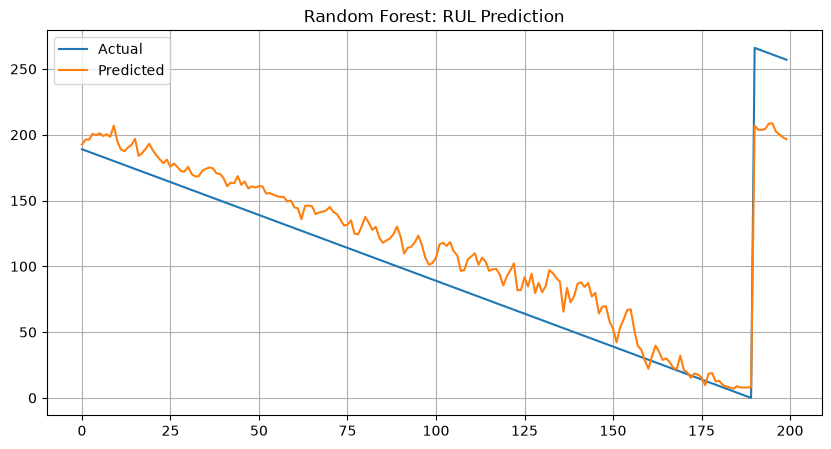

In [36]:
# Plot prediction
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(y_val.values[:200], label="Actual")
plt.plot(y_pred_val[:200], label="Predicted")
plt.title("Random Forest: RUL Prediction")
plt.legend()
plt.grid()
plt.show()

## Model comparison table

The validation-set results for the models trained in this notebook are summarized below:

| Model | Dataset | RMSE | MAE | R² |
|---|---|---:|---:|---:|
| Random Forest (Optuna-tuned) | Validation | 29.3688 | 22.7863 | 0.7967 |
| XGBoost (Optuna-tuned) | Validation | 29.1636 | 22.6656 | 0.7995 |

These results suggest that the XGBoost model outperformed the Random Forest baseline on the validation set for this task.

### Interpretable / Explainable predictions using SHAP

In [37]:
import shap

X_sample = X_val.sample(n=10, random_state=42)

explainer = shap.TreeExplainer(best_xg)
shap_values = explainer(X_sample)



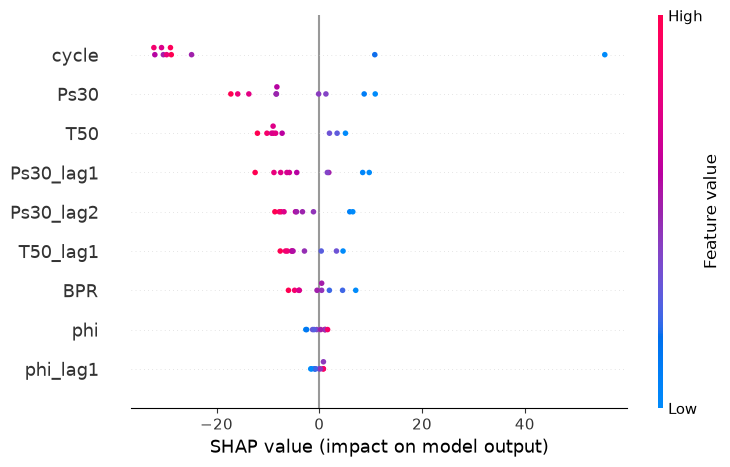

In [38]:
shap.plots.beeswarm(shap_values)

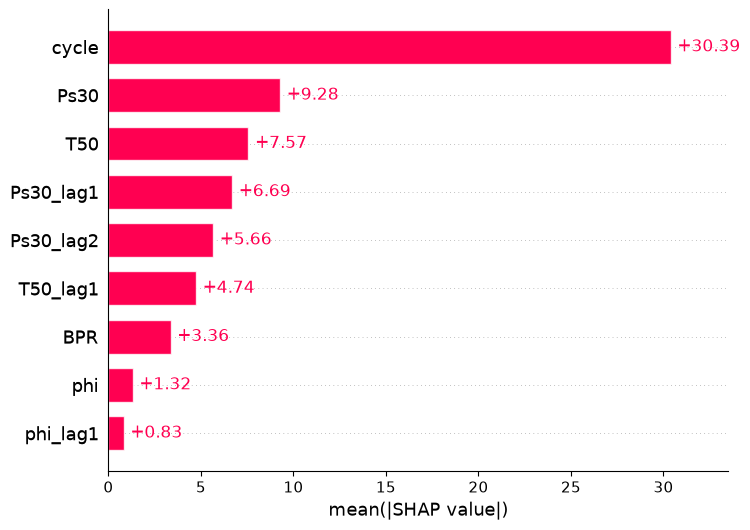

In [39]:
shap.plots.bar(shap_values)

Based on the SHAP plots, `cycle` contributes by far the most to the prediction,
followed by `Ps30` (static pressure at HPC outlet) and `T50`, then their lag/rolling
variants and `BPR`. Rolling/lag statistics of `Ps30` and `T50` clearly carry useful
signal beyond the instantaneous readings.

# Evaluation on test set

In [40]:
import pandas as pd
from src.const import RAW_COLUMN_NAMES

# Read raw test data using the same schema as the training data
columns = RAW_COLUMN_NAMES

# Load the raw test file and the provided RUL values
raw_test = pd.read_csv(
    "../data/raw/test_FD001.txt",
    sep=r"\s+",
    header=None,
    usecols=range(len(columns)),
    names=columns,
    engine="python",
)
raw_rul = pd.read_csv("../data/raw/RUL_FD001.txt", sep=r"\s+", header=None).iloc[:, 0]

# Apply the same preprocessing as training data
raw_test = preprocess(raw_test, cols_to_drop=cols_to_drop)

# Reconstruct RUL for every observed cycle using the provided terminal RUL values
engine_ids = raw_test["engine_id"].unique()
if len(raw_rul) != len(engine_ids):
    raise ValueError(f"Expected {len(engine_ids)} RUL values, got {len(raw_rul)}")

rul_map = dict(zip(engine_ids, raw_rul.tolist()))
raw_test["rul_at_last_cycle"] = raw_test["engine_id"].map(rul_map)
raw_test["last_cycle"] = raw_test.groupby("engine_id")["cycle"].transform("max")
raw_test["RUL"] = raw_test["rul_at_last_cycle"] + (raw_test["last_cycle"] - raw_test["cycle"])
raw_test = raw_test.drop(columns=["rul_at_last_cycle", "last_cycle"])

# Scale using the training-set scaler and create the same engineered features
sensor_cols = get_sensor_columns(raw_test)
raw_test_scaled = raw_test.copy()
raw_test_scaled[sensor_cols] = scaler.transform(raw_test_scaled[sensor_cols])

raw_test_fe = add_time_series_features(raw_test_scaled, sensor_cols)
raw_test_fe = raw_test_fe.dropna().reset_index(drop=True)

# Keep the same feature columns used during model training
raw_test_final = apply_feature_selection(raw_test_fe, selected_features)

# Collect processed test data for later evaluation
test_data_processed = [raw_test_final]
test_data_processed = pd.concat(test_data_processed, ignore_index=True)

print("Test preprocessing complete.")
test_data_processed.head()


Test preprocessing complete.


,RUL,cycle,engine_id,Ps30,T50,Ps30_lag1,phi,T50_lag1,Ps30_lag2,phi_lag1,BPR
0,140,3,1,-0.149293,-0.840916,-0.149293,0.752310,-1.501236,-1.278278,1.010825,0.055314
1,139,4,1,-0.977215,-0.274289,-0.149293,-0.050446,-0.840916,-0.149293,0.752310,-1.341760
2,138,5,1,-0.864317,-0.776222,-0.977215,0.997219,-0.274289,-0.149293,-0.050446,-1.037816
3,137,6,1,-1.052481,-1.533583,-0.864317,0.684280,-0.776222,-0.977215,0.997219,-0.485919
4,136,7,1,-0.864317,-0.450523,-1.052481,0.806734,-1.533583,-0.864317,0.684280,-1.349758


In [41]:
train_final.columns

Index(['RUL', 'cycle', 'engine_id', 'Ps30', 'T50', 'Ps30_lag1', 'phi',
       'T50_lag1', 'Ps30_lag2', 'phi_lag1', 'BPR'],
      dtype='object')

In [42]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Prepare features and target for evaluation
X_test = test_data_processed.drop(columns=["RUL", "engine_id"], errors="ignore")
y_test = test_data_processed["RUL"]

# Use the trained model from the notebook
if "best_xg" not in globals():
    raise NameError("Train a model first (for example, fit best_xg on X_train/y_train).")

# Predict on the test set
y_pred_test = best_xg.predict(X_test)

# Compute evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae = mean_absolute_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print("\nTest Performance:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R2  : {r2:.4f}")



Test Performance:
RMSE: 41.3785
MAE : 31.4618
R2  : 0.5021


# Error Analysis

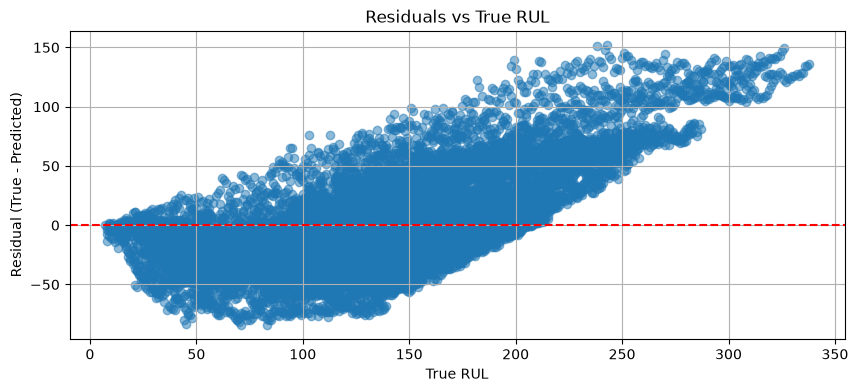

In [43]:
residuals = y_test - y_pred_test

plt.figure(figsize=(10, 4))
plt.scatter(y_test, residuals, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("True RUL")
plt.ylabel("Residual (True - Predicted)")
plt.title("Residuals vs True RUL")
plt.grid(True)
plt.show()

Model tends to overpredict RUL, hence negative values near smaller RUL.

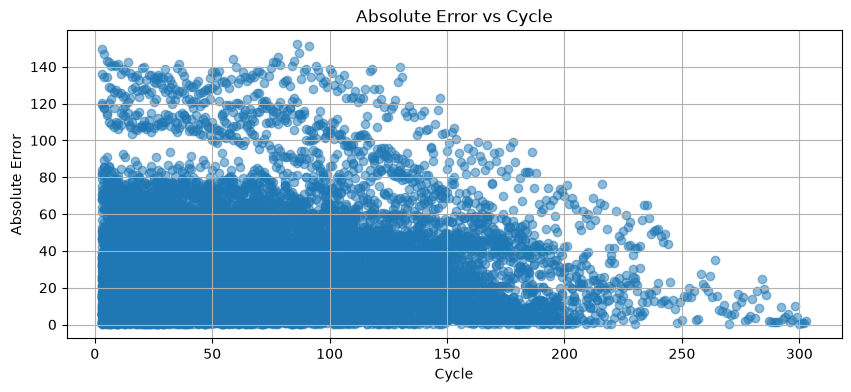

In [44]:
### Error by cycle
plt.figure(figsize=(10, 4))
plt.scatter(test_data_processed["cycle"], np.abs(residuals), alpha=0.5)
plt.xlabel("Cycle")
plt.ylabel("Absolute Error")
plt.title("Absolute Error vs Cycle")
plt.grid(True)
plt.show()


Error is lower near failure, more accurate closer to failure

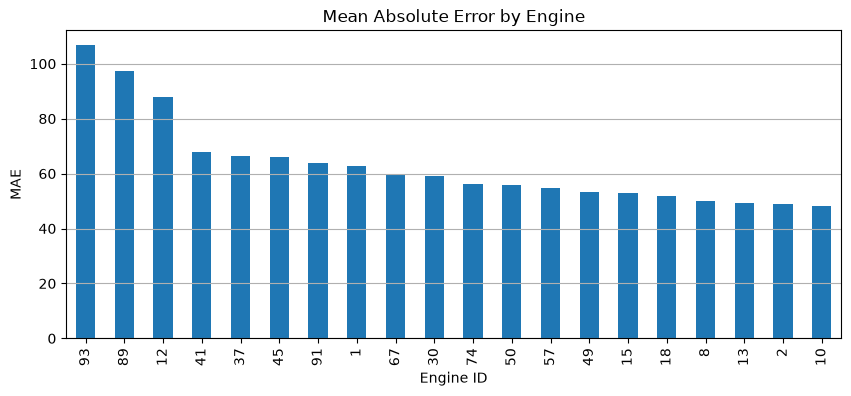

In [45]:
### Error by engine
engine_errors = pd.DataFrame({
    "engine_id": test_data_processed["engine_id"],
    "abs_error": np.abs(residuals)
}).groupby("engine_id")["abs_error"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
engine_errors.head(20).plot(kind="bar")
plt.title("Mean Absolute Error by Engine")
plt.ylabel("MAE")
plt.xlabel("Engine ID")
plt.grid(axis="y")
plt.show()

Engine 93 has the highest errors

# Classification Evaluation via binning


When RUL is below 30 cycles, we treat the engine as being in a near-failure state and flag it for maintenance attention. This is often more actionable from a business perspective than reporting a raw RUL number, because it supports clear operational decisions such as scheduling inspection, maintenance, or replacement.

In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import classification_report

# Note: threshold should not be tuned using test set
def binary_evaluation(threshold=30, pred_offset=0):
    # Convert continuous RUL into a binary class: 1 = near failure, 0 = not near failure
    y_true_bin = (y_test <= threshold).astype(int)
    y_pred_bin = (y_pred_test <= threshold + pred_offset).astype(int)

    accuracy = accuracy_score(y_true_bin, y_pred_bin)
    precision = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    recall = recall_score(y_true_bin, y_pred_bin, zero_division=0)
    f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)
    cm = confusion_matrix(y_true_bin, y_pred_bin)

    print("Binary Classification Metrics")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true_bin, y_pred_bin, target_names=["Not Near Failure", "Near Failure"]))

    # Optional: plot confusion matrix
    import seaborn as sns
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Near Failure", "Near Failure"], yticklabels=["Not Near Failure", "Near Failure"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix for Near-Failure Classification")
    plt.show()


Binary Classification Metrics
Accuracy : 0.9853
Precision: 0.8295
Recall   : 0.5422
F1-score : 0.6557

Classification Report:
                  precision    recall  f1-score   support

Not Near Failure       0.99      1.00      0.99     12564
    Near Failure       0.83      0.54      0.66       332

        accuracy                           0.99     12896
       macro avg       0.91      0.77      0.82     12896
    weighted avg       0.98      0.99      0.98     12896



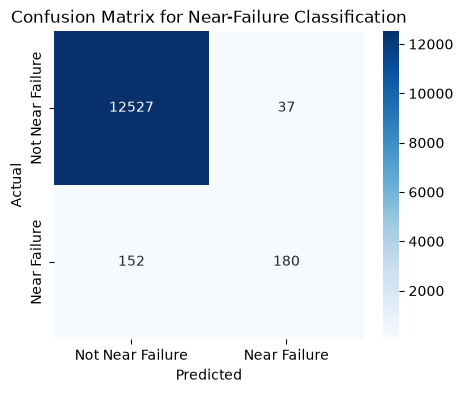

In [47]:
binary_evaluation()

Binary Classification Metrics
Accuracy : 0.9827
Precision: 0.6518
Recall   : 0.7048
F1-score : 0.6773

Classification Report:
                  precision    recall  f1-score   support

Not Near Failure       0.99      0.99      0.99     12564
    Near Failure       0.65      0.70      0.68       332

        accuracy                           0.98     12896
       macro avg       0.82      0.85      0.83     12896
    weighted avg       0.98      0.98      0.98     12896



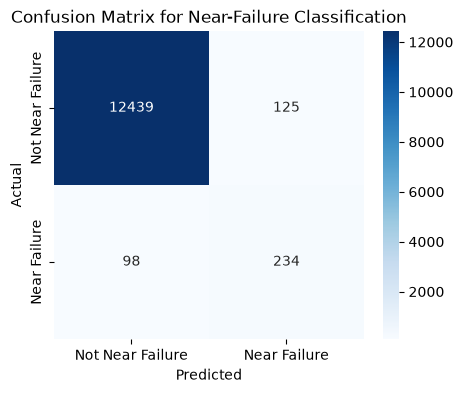

In [48]:
binary_evaluation(pred_offset=10)

Because the model tends to overpredict RUL at lower values, we can apply a positive prediction offset to make the system more conservative and flag more cases as near failure. Increasing the offset generally improves recall but reduces precision, which allows the business to choose the desired tradeoff between catching more risky engines and avoiding extra false alarms.

Example:

Model with offset=0:
- precision = 0.83
- recall = 0.54

Model with offset=10:
- precision = 0.65
- recall = 0.70

## Future work for model improvements

Several next steps could further improve the model and make the results more robust:

- Add a baseline model comparison table, including simple baselines and more advanced models, to better quantify the gain from the current approach.
- Run an ablation study for lag and rolling features to measure how much each feature group contributes to predictive performance.
- Combine multiple datasets or operating conditions to improve generalization and reduce overfitting to a single fleet or regime.
